# Taller 1 · Del voltaje crudo a la figura
Gabriel Garcia, A.Catalina Barajas
**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [ ]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

descargado: taller1_datos.h5
descargado: verificacion.py
Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [ ]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [ ]:



# -------------------------------------------------------------------------
# 1. RUTA DEL ARCHIVO
# -------------------------------------------------------------------------

# Indicamos la ubicación del archivo HDF5.
ruta_archivo = "/content/taller1_datos.h5"


# -------------------------------------------------------------------------
# 2. ABRIR EL ARCHIVO
# -------------------------------------------------------------------------

# Abrimos el archivo HDF5 en modo lectura.
with h5py.File(ruta_archivo, "r") as archivo:

    # ---------------------------------------------------------------
    # ATRIBUTOS DEL ARCHIVO
    # ---------------------------------------------------------------

    # Mostramos un título para identificar esta sección.
    print("=" * 70)
    print("ATRIBUTOS DEL ARCHIVO")
    print("=" * 70)

    # Comprobamos si el archivo tiene atributos.
    if len(archivo.attrs) > 0:

        # Recorremos todos los atributos del archivo.
        for atributo, valor in archivo.attrs.items():

            # Mostramos el nombre y el contenido de cada atributo.
            print(f"{atributo} = {valor}")

    # Si no existen atributos, mostramos un mensaje.
    else:
        print("El archivo no tiene atributos.")


    # ---------------------------------------------------------------
    # 3. ACCEDER AL GRUPO "estimulos"
    # ---------------------------------------------------------------

    # Accedemos al grupo llamado "estimulos".
    estimulos = archivo["estimulos"]


    # ---------------------------------------------------------------
    # 4. MOSTRAR LOS ATRIBUTOS DE "estimulos"
    # ---------------------------------------------------------------

    # Mostramos un título para esta sección.
    print("\n" + "=" * 70)
    print("ATRIBUTOS DEL GRUPO 'estimulos'")
    print("=" * 70)

    # Recorremos todos los atributos del grupo estimulos.
    for atributo, valor in estimulos.attrs.items():

        # Mostramos el nombre y el valor del atributo.
        print(f"{atributo} = {valor}")


    # ---------------------------------------------------------------
    # 5. MOSTRAR EL CONTENIDO DE "estimulos"
    # ---------------------------------------------------------------

    # Mostramos un título para esta sección.
    print("\n" + "=" * 70)
    print("CONTENIDO DEL GRUPO 'estimulos'")
    print("=" * 70)

    # Recorremos todos los elementos que existen dentro de estimulos.
    for nombre, elemento in estimulos.items():

        # Mostramos el nombre del elemento.
        print(f"\nElemento: {nombre}")

        # Comprobamos si el elemento es un dataset.
        if isinstance(elemento, h5py.Dataset):

            # Mostramos la forma del dataset.
            print(f"Shape: {elemento.shape}")

            # Mostramos el tipo de dato.
            print(f"Tipo: {elemento.dtype}")

            # Mostramos los primeros valores del dataset.
            print(f"Primeros valores: {elemento[:10]}")


    # ---------------------------------------------------------------
    # 6. CONTAR LOS ENSAYOS
    # ---------------------------------------------------------------

    # Obtenemos el dataset que contiene las condiciones.
    condicion = estimulos["condicion"][:]

    # El número de elementos de condicion corresponde al número de ensayos.
    numero_ensayos = len(condicion)

    # Mostramos el número total de ensayos.
    print("\n" + "=" * 70)
    print("NÚMERO DE ENSAYOS")
    print("=" * 70)

    # Imprimimos el número total de ensayos.
    print(f"Número total de ensayos: {numero_ensayos}")


    # ---------------------------------------------------------------
    # 7. IDENTIFICAR LAS CONDICIONES DISTINTAS
    # ---------------------------------------------------------------

    # Obtenemos las condiciones diferentes que aparecen en el dataset.
    condiciones_unicas = np.unique(condicion)

    # Mostramos las condiciones encontradas.
    print("\n" + "=" * 70)
    print("CONDICIONES DE ESTÍMULO")
    print("=" * 70)

    # Mostramos las condiciones.
    print(f"Condiciones encontradas: {condiciones_unicas}")

    # Contamos cuántas condiciones diferentes existen.
    numero_condiciones = len(condiciones_unicas)

    # Mostramos el número de condiciones.
    print(f"Número de condiciones distintas: {numero_condiciones}")


    # ---------------------------------------------------------------
    # 8. CONTAR LOS ENSAYOS DE CADA CONDICIÓN
    # ---------------------------------------------------------------

    # Recorremos cada condición encontrada.
    for condicion_actual in condiciones_unicas:

        # Contamos cuántos ensayos pertenecen a esta condición.
        cantidad = np.sum(condicion == condicion_actual)

        # Convertimos el nombre de la condición de bytes a texto.
        nombre_condicion = condicion_actual.decode("utf-8")

        # Mostramos cuántos ensayos tiene esta condición.
        print(
            f"Condición {nombre_condicion}: "
            f"{cantidad} ensayos"
        )


    # ---------------------------------------------------------------
    # 9. OBTENER LOS TIEMPOS DE INICIO
    # ---------------------------------------------------------------

    # Obtenemos el dataset que contiene el tiempo de inicio de cada ensayo.
    tiempo_inicio = estimulos["tiempo_inicio_s"][:]

    # Mostramos los tiempos de inicio.
    print("\n" + "=" * 70)
    print("TIEMPOS DE INICIO")
    print("=" * 70)

    # Mostramos los primeros diez tiempos de inicio.
    print("Primeros 10 tiempos de inicio:")
    print(tiempo_inicio[:10])


    # ---------------------------------------------------------------
    # 10. CALCULAR LA SEPARACIÓN ENTRE ENSAYOS
    # ---------------------------------------------------------------

    # Calculamos la diferencia entre tiempos de inicio consecutivos.
    diferencias = np.diff(tiempo_inicio)

    # Obtenemos los valores de separación diferentes.
    diferencias_unicas = np.unique(diferencias)

    # Mostramos las diferencias encontradas.
    print("\nSeparación entre inicios de ensayos:")
    print(diferencias_unicas)


    # ---------------------------------------------------------------
    # 11. DURACIÓN DEL ENSAYO
    # ---------------------------------------------------------------

    # Como los tiempos de inicio son 30, 33, 36, 39..., cada ensayo
    # comienza 3 segundos después del anterior.
    duracion_ensayo = diferencias_unicas[0]

    # Mostramos la duración calculada del ensayo.
    print("\n" + "=" * 70)
    print("DURACIÓN DEL ENSAYO")
    print("=" * 70)

    # Imprimimos la duración del ensayo en segundos.
    print(f"Duración de un ensayo: {duracion_ensayo} segundos")


    # ---------------------------------------------------------------
    # 12. DURACIÓN DEL ESTÍMULO
    # ---------------------------------------------------------------

    # Comprobamos si existe un atributo relacionado con la duración
    # del estímulo dentro del grupo estimulos.
    posibles_atributos = [
        "duracion_estimulo",
        "duracion_estímulo",
        "estimulo_duracion_s",
        "duracion_estimulo_s",
        "stimulus_duration",
        "stimulus_duration_s"
    ]

    # Inicializamos la variable que almacenará la duración.
    duracion_estimulo = None

    # Recorremos los nombres posibles de atributos.
    for nombre_atributo in posibles_atributos:

        # Comprobamos si ese atributo existe.
        if nombre_atributo in estimulos.attrs:

            # Guardamos el valor del atributo.
            duracion_estimulo = estimulos.attrs[nombre_atributo]

            # Salimos del bucle porque ya encontramos el atributo.
            break


    # ---------------------------------------------------------------
    # 13. MOSTRAR LA DURACIÓN DEL ESTÍMULO
    # ---------------------------------------------------------------

    # Mostramos una sección específica para la duración del estímulo.
    print("\n" + "=" * 70)
    print("DURACIÓN DEL ESTÍMULO")
    print("=" * 70)

    # Comprobamos si encontramos el atributo.
    if duracion_estimulo is not None:

        # Mostramos la duración del estímulo.
        print(f"Duración del estímulo: {duracion_estimulo} segundos")

    # Si no encontramos el atributo, mostramos todos los atributos
    # disponibles para identificarlo.
    else:

        # Informamos de que no encontramos automáticamente el atributo.
        print("No se encontró automáticamente el atributo de duración.")

        # Mostramos los atributos disponibles.
        print("Atributos disponibles en 'estimulos':")

        # Recorremos los atributos disponibles.
        for atributo, valor in estimulos.attrs.items():

            # Mostramos cada atributo y su valor.
            print(f"    {atributo} = {valor}")



ATRIBUTOS DEL ARCHIVO
descripcion = Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
duracion_s = 210.0
escala_uV_por_bit = 0.195
frecuencia_muestreo_hz = 20000
n_canales = 1
unidades = microvoltios tras multiplicar por escala_uV_por_bit

ATRIBUTOS DEL GRUPO 'estimulos'
duracion_estimulo_s = 0.5
duracion_post_s = 1.5
duracion_pre_s = 1.0
nota = tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.

CONTENIDO DEL GRUPO 'estimulos'

Elemento: condicion
Shape: (60,)
Tipo: |S1
Primeros valores: [b'B' b'B' b'C' b'A' b'A' b'A' b'C' b'A' b'C' b'B']

Elemento: tiempo_inicio_s
Shape: (60,)
Tipo: float64
Primeros valores: [30. 33. 36. 39. 42. 45. 48. 51. 54. 57.]

NÚMERO DE ENSAYOS
Número total de ensayos: 60

CONDICIONES DE ESTÍMULO
Condiciones encontradas: [b'A' b'B' b'C']
Número de condiciones distintas: 3
Condición A: 20 ensayos
Condición B: 20 ensayos
Condición C: 20 ensayos

TIEMPOS DE INICIO
Primeros

In [ ]:
# Abrimos el archivo HDF5 en modo lectura.
with h5py.File(ruta_archivo, "r") as archivo:

    # Accedemos al grupo estimulos.
    estimulos = archivo["estimulos"]

    # Recorremos todo lo que hay dentro de estimulos.
    for nombre, elemento in estimulos.items():

        # Mostramos el nombre del elemento.
        print("\nNombre:", nombre)

        # Comprobamos si es un dataset.
        if isinstance(elemento, h5py.Dataset):

            # Mostramos la forma del dataset.
            print("Shape:", elemento.shape)

            # Mostramos el tipo de datos.
            print("Tipo:", elemento.dtype)

            # Leemos los datos.
            datos = elemento[:]

            # Mostramos los primeros 20 valores.
            print("Primeros 20 valores:", datos[:20])

            # Mostramos los valores únicos si es posible.
            try:
                print("Valores únicos:", np.unique(datos))
            except:
                print("No se pudieron calcular los valores únicos.")

        # Si es un grupo, indicamos que es un grupo.
        elif isinstance(elemento, h5py.Group):

            # Mostramos que se trata de un grupo.
            print("Es un GRUPO")



Nombre: condicion
Shape: (60,)
Tipo: |S1
Primeros 20 valores: [b'B' b'B' b'C' b'A' b'A' b'A' b'C' b'A' b'C' b'B' b'B' b'B' b'A' b'C'
 b'C' b'B' b'C' b'C' b'A' b'C']
Valores únicos: [b'A' b'B' b'C']

Nombre: tiempo_inicio_s
Shape: (60,)
Tipo: float64
Primeros 20 valores: [30. 33. 36. 39. 42. 45. 48. 51. 54. 57. 60. 63. 66. 69. 72. 75. 78. 81.
 84. 87.]
Valores únicos: [ 30.  33.  36.  39.  42.  45.  48.  51.  54.  57.  60.  63.  66.  69.
  72.  75.  78.  81.  84.  87.  90.  93.  96.  99. 102. 105. 108. 111.
 114. 117. 120. 123. 126. 129. 132. 135. 138. 141. 144. 147. 150. 153.
 156. 159. 162. 165. 168. 171. 174. 177. 180. 183. 186. 189. 192. 195.
 198. 201. 204. 207.]


**Lo que encontramos en el archivo:**

- ensayos: 60
- condiciones: 3
- duración del ensayo: 3 s · pre-estímulo: 1 s · estímulo: 0.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

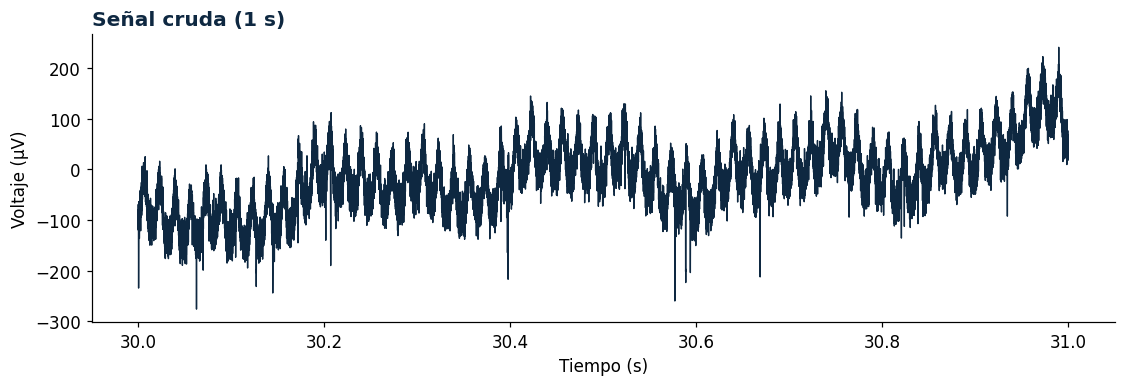

In [ ]:

def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    m = (t >= t0) & (t <t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot( t[m],cruda[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                          # no olvides las unidades
    plt.ylabel("Voltaje (µV)")

ver(cruda, "Señal cruda (1 s)", t0=30, t1=31)





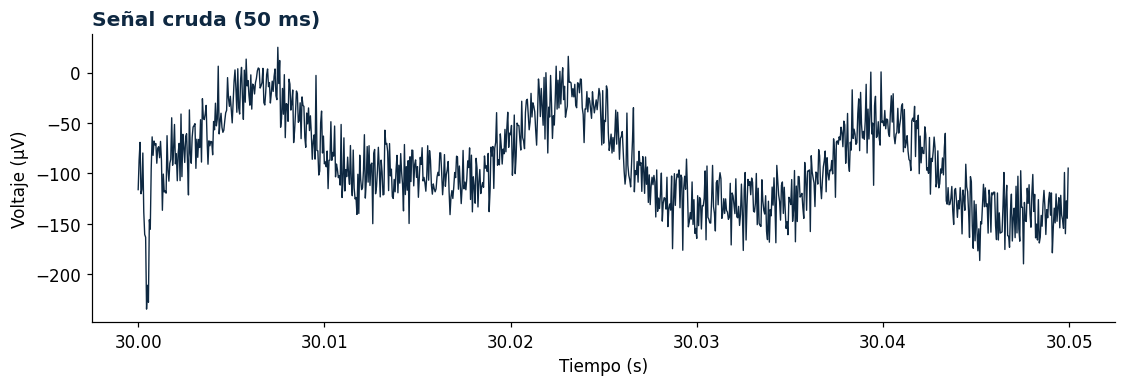

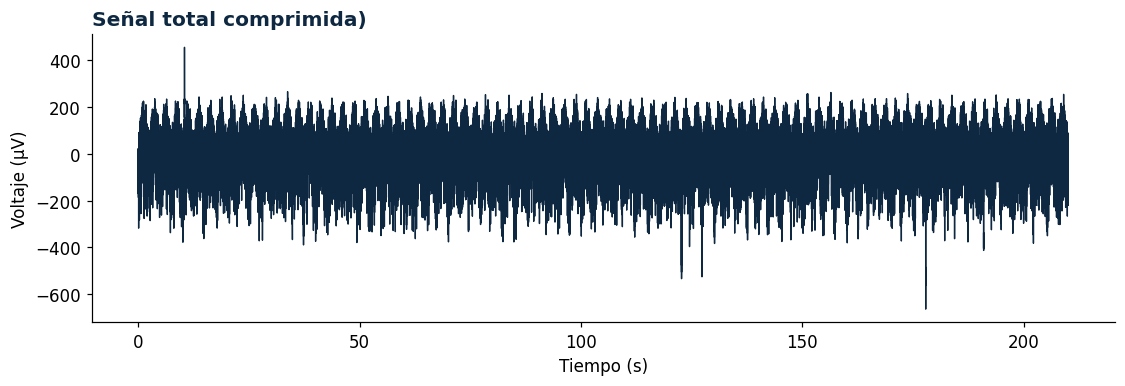

In [ ]:
def ver(x, titulo, t0=30.0, t1=30.05, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    m = (t >= t0) & (t <t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot( t[m],cruda[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                          # no olvides las unidades
    plt.ylabel("Voltaje (µV)")

ver(cruda, "Señal cruda (50 ms)", t0=30, t1=30.05)


def ver(x, titulo, t0=0, t1=210, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    m = (t >= t0) & (t <t1)                  # máscara: True donde el tiempo cae en la ventana
    plt.figure()
    plt.plot( t[m],cruda[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y?
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")                          # no olvides las unidades
    plt.ylabel("Voltaje (µV)")
ver(cruda, "Señal total comprimida)", t0=0, t1=210)

**Los tres problemas que encontramos:**

1.Ruido por Red electrica (60hz)
2.Deriva lenta (0.4hz)(ruido termico o biologicas)
3.Ruido por movimiento de un cable externo (artefactos)

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos
en la Sesión 3? Deriva lenta ya que las oscilaciones hacen dificl la interpretacion de los picos del potencial de accion.

---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

PROMT original : Trabajo en google collab, en python. Necesito una función espectro() que grafique un espectro de potencia neuronal. Este tiene que tener como entrada un variable llamada "x" que sea un array de voltaje, una variable "fs" que es frecuencia de muestreo, una variable "etiqueta" que es el titulo del grafico, y una variable "fmax" que es igual a 500. Ademas, tiene que tene como salida dos arrays: la variable "f" que es (frecuencias, Hz) y la variable "P" que es (potencia en cada frecuencia). Hazlo usando las variables scipy.signal.welch y nperseg=8192; y Grafica solo hasta fmax, con el eje y en escala logarítmica (plt.semilogy), ejes rotulados con unidades. Explica en el mismo codigo en comentarios que hace cada linea. Tambien ten en cuenta que estas tres lineas ya vienen incluidas en el codigo, asi que integralas

(m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")


CORRECCIONES: El literal b de la verificacion fallaba ("FALLA las frecuencias llegan hasta Nyquist (10 000 Hz)  ->  pista: grafiquen solo hasta fmax, pero calculen el espectro completo"), asi que eliminé las líneas f = f[mascara_fmax] / P = P[mascara_fmax] que reasignaban las variables. Ahora mascara_fmax se usa únicamente dentro de plt.semilogy(...), así que el gráfico se ve igual que antes (solo hasta fmax), pero f y P conservan todo el rango hasta Nyquist (10000 Hz con tu fs=20000), que es justo lo que pide el chequeo automático.

>

Pico dominante entre 40 y 200 Hz: 61.0 Hz


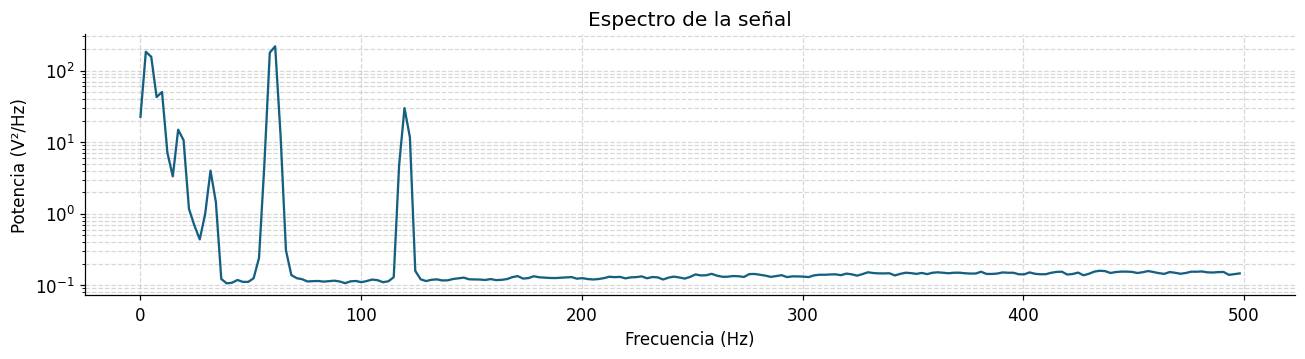

In [ ]:
def espectro(x, fs, etiqueta, fmax=500):
    """
    Calcula y grafica el espectro de potencia de una señal de voltaje.

    Parámetros:
        x       : array con la señal de voltaje (V o mV)
        fs      : frecuencia de muestreo (Hz)
        etiqueta: título del gráfico
        fmax    : frecuencia máxima a GRAFICAR (Hz), por defecto 500

    Retorna:
        f : array de frecuencias (Hz), COMPLETO hasta Nyquist (fs/2)
        P : array de potencia, COMPLETO (misma longitud que f)
    """

    # Calcula la densidad espectral de potencia (PSD) completa con Welch,
    # desde 0 Hz hasta Nyquist = fs/2
    f, P = welch(x, fs=fs, nperseg=8192)

    # Máscara SOLO para graficar hasta fmax; no se usa para modificar f ni P
    mascara_fmax = f <= fmax

    # Abre una figura nueva para el gráfico
    plt.figure()

    # Grafica en escala log, usando la máscara únicamente en esta línea
    plt.semilogy(f[mascara_fmax], P[mascara_fmax], color=TEAL)

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Potencia (V²/Hz)")
    plt.title(etiqueta)
    plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.tight_layout()

    # --- Bloque ya incluido: detección del pico dominante entre 40 y 200 Hz ---
    # Como f y P ahora son el espectro COMPLETO, esto funciona sin depender de fmax
    m = (f > 40) & (f < 200)
    pico = float(f[m][np.argmax(P[m])])
    print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")
    # --- Fin del bloque incluido ---

    plt.show()

    # Retorna f y P COMPLETOS (hasta Nyquist), sin recortar
    return f, P

f, P = espectro(cruda, fs, etiqueta="Espectro de la señal")


In [ ]:
# ✅ VERIFICACIÓN · ejercicio C1
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

Pico dominante entre 40 y 200 Hz: 61.0 Hz
  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_

## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_**Escriban aquí su prompt:**_

Tengo un trabajo en Google Collab, en el idioma pyhon y estoy usando este set de datos :
 (pegar la parte 0 de este taller)

Necesito una funcion capaz de filtrar la señal cruda (guardada en la variable "cruda") que tenga como entradas la variable	"x" (señal),  la variable "fs" (frecuencia de muestreo en Hz), la variable " baja=None" (corte inferior), la variable "alta=None " (corte superior),  y un orden=3. Ademas, la variable de salida debe ser  la señal filtrada, del mismo tamaño que x. Necesito que lo hagas a traves del filtro Butterworth; si solo se da alta, es pasa-bajos; si solo se da baja, es pasa-altos; si se dan las dos, pasa-banda. Ademas, ES IMPERATIVO, que la funcion tenga una  fase cero (filtfilt o sosfiltfilt) y frecuencias normalizadas por Nyquist. Por ultimo, ten en cuenta que esto ya me lo dan en el codigo :
(pegar las funciones para graficar la señal del punto D1)
Explicame en comentarios que haces en cada paso del codigo

No fueron necesarias cotrrecciones
>

<Figure size 1320x374 with 0 Axes>

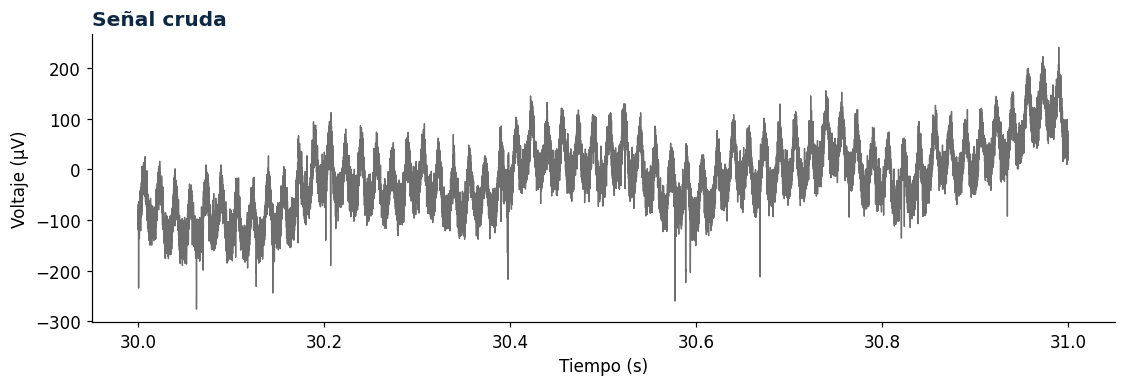

<Figure size 1320x374 with 0 Axes>

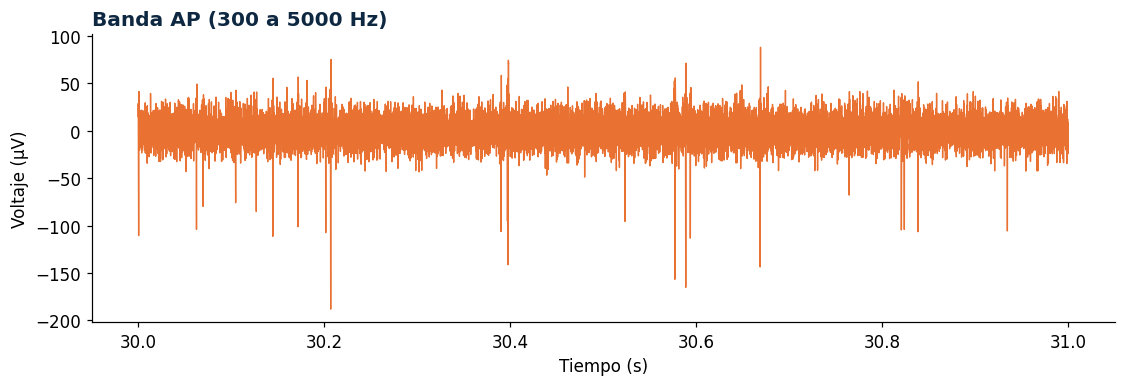

In [ ]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.
def filtrar(x, fs, baja=None, alta=None, orden=3):
    """
    Filtra la señal x usando un filtro Butterworth de fase cero.

    Parámetros
    ----------
    x     : señal cruda (array 1D)
    fs    : frecuencia de muestreo en Hz
    baja  : corte inferior (Hz). Si se da, deja pasar frecuencias por ENCIMA de este valor.
    alta  : corte superior (Hz). Si se da, deja pasar frecuencias por DEBAJO de este valor.
    orden : orden del filtro Butterworth (por defecto 3)

    Retorna
    -------
    señal filtrada, mismo tamaño que x
        - solo 'alta'        -> pasa-bajos
        - solo 'baja'        -> pasa-altos
        - 'baja' y 'alta'    -> pasa-banda
    """

    # 1) La frecuencia de Nyquist es la máxima frecuencia representable
    #    dado el muestreo (fs/2). Butterworth en scipy pide las frecuencias
    #    de corte NORMALIZADAS respecto a esta (valores entre 0 y 1).
    nyq = fs / 2.0

    # 2) Según qué cortes se dieron, decidimos el tipo de filtro y armamos
    #    el arreglo de frecuencias de corte normalizadas (Wn).
    if baja is not None and alta is not None:
        # Pasa-banda: deja pasar solo lo que está ENTRE baja y alta
        tipo = "bandpass"
        Wn = [baja / nyq, alta / nyq]
    elif alta is not None:
        # Pasa-bajos: deja pasar frecuencias por debajo de 'alta'
        tipo = "lowpass"
        Wn = alta / nyq
    elif baja is not None:
        # Pasa-altos: deja pasar frecuencias por encima de 'baja'
        tipo = "highpass"
        Wn = baja / nyq
    else:
        # Si no se especificó ningún corte, no hay nada que filtrar
        raise ValueError("Debe especificarse 'baja', 'alta' o ambas.")

    # 3) Diseñamos el filtro Butterworth en formato SOS (second-order sections).
    #    SOS es numéricamente más estable que la forma clásica (b, a),
    #    especialmente en órdenes altos o bandas angostas, evitando
    #    problemas de precisión numérica.
    sos = butter(orden, Wn, btype=tipo, output="sos")

    # 4) Aplicamos el filtro con sosfiltfilt, que filtra la señal
    #    hacia adelante y hacia atrás. Esto cancela el desfase (retardo)
    #    que introduciría un filtro normal, dejando la señal filtrada
    #    perfectamente alineada en el tiempo con la señal original
    #    (fase cero). Por eso la salida tiene el mismo tamaño que x.
    from scipy.signal import sosfiltfilt
    y = sosfiltfilt(sos, x)

    return y

def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1."""
    m = (t >= t0) & (t < t1)

    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)

    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (µV)")
    plt.show()

AP = filtrar(cruda, fs=20000, baja=300, alta=5000, orden=3)   # pasa-banda de 300 a 5000 Hz sobre la señal cruda

plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?

La deriva se eliminio por completo , es decir que la señal quedo perfectamente centrada en 0 microvolteos . Y los artefactos desapareciron casi en su totalidad al atenuars las componentes de baja frecuencia y gran amplitud.

- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

  Cuando queremos eliminar un único tipo de frecuencia especifica , como por ejemplo lso 60 Hz


### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

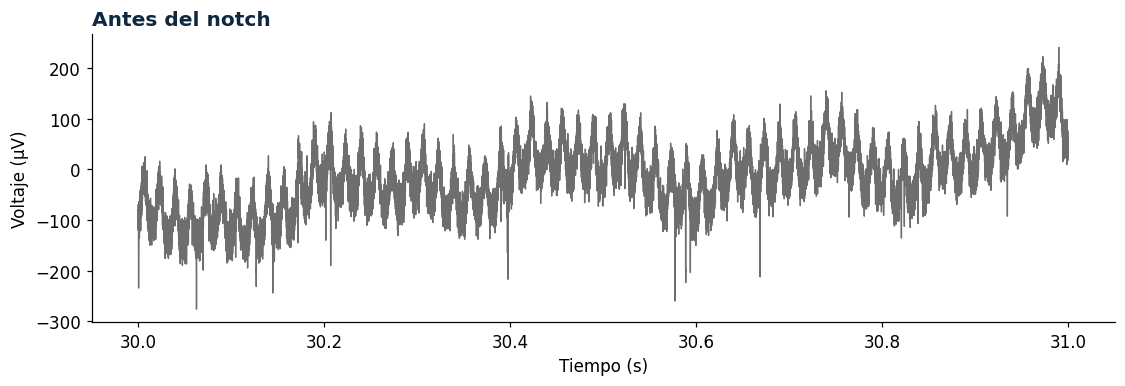

<Figure size 1320x374 with 0 Axes>

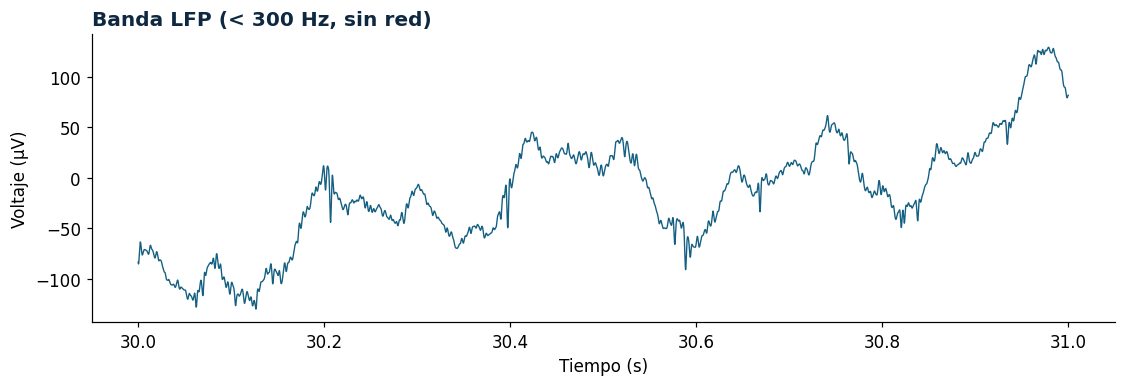

In [ ]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.
def notch(x, f0, fs, Q=30):
    """
    Elimina una frecuencia puntual (ej. ruido de red eléctrica) de una señal,
    usando un filtro notch (rechaza-banda muy angosto) IIR con fase cero.

    Parámetros
    ----------
    x   : señal a filtrar (array 1D), en las unidades que sea (aquí µV)
    f0  : frecuencia a eliminar, en Hz (ej. 60.0 para ruido de red en Colombia/EE.UU.)
    fs  : frecuencia de muestreo, en Hz (aquí 20000 Hz)
    Q   : factor de calidad del notch (adimensional). Controla qué tan angosto
          es el "hueco" que se elimina alrededor de f0. Por defecto 30.

    Retorna
    -------
    señal filtrada, mismo tamaño que x, con la componente en f0 (Hz) atenuada
    """

    # 1) Igual que con Butterworth, iirnotch pide la frecuencia normalizada
    #    respecto a Nyquist (fs/2 Hz), en un rango de 0 a 1.
    #    f0 está en Hz, fs en Hz -> w0 es adimensional.
    nyq = fs / 2.0
    w0 = f0 / nyq

    # 2) Diseñamos el filtro notch: b y a son los coeficientes del filtro
    #    IIR (respuesta al impulso infinita) que crean un "hueco" muy
    #    angosto en la frecuencia f0, dejando casi intactas las frecuencias
    #    vecinas.
    b, a = iirnotch(w0, Q)

    # 3) Aplicamos el filtro con filtfilt (fase cero): filtra hacia adelante
    #    y hacia atrás, cancelando el retardo de fase. y tiene el mismo
    #    tamaño (en muestras) que x.
    y = filtfilt(b, a, x)

    return y

def ver(x, titulo, t0=30.0, t1=31.0, color= NAVY):
    """Grafica la señal x entre los tiempos t0 y t1."""
    m = (t >= t0) & (t < t1)

    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)

    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (µV)")
    plt.show()

sin_60Hz  = notch(cruda,     f0=60,  fs=20000, Q=30) # la señal cruda sin ruido de red
sin_red = notch(sin_60Hz,  f0=120, fs=20000, Q=30)# pasa-bajos de 300 Hz sobre sin_red
LFP = filtrar(sin_red, fs, alta=300, orden=3)

plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.

- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

El diagnóstico va primero para identificar qué frecuencias contienen ruido y cuáles señal biológica real, evitando así aplicar filtros que distorsionen o eliminen datos de interés.

---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [ ]:
#def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    #"""Devuelve los índices de las muestras donde hay un potencial de acción."""


import numpy as np

def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """
    Detecta los índices de muestras donde ocurren potenciales de acción (spikes).

    Parámetros:
        x         : np.ndarray, señal filtrada en µV.
        fs        : float/int, frecuencia de muestreo en Hz.
        k         : float, multiplicador para definir el umbral en función del ruido.
        muerto_ms : float, tiempo mínimo de refractariedad/bloqueo entre disparos en milisegundos.

    Devuelve:
        np.ndarray de enteros con los índices de cada disparo, ordenados y sin repetir.
    """
    # -------------------------------------------------------------------------
    # DECISIÓN 1: Orientación del potencial de acción extracelular
    # Los registros extracelulares muestran picos negativos principales debido
    # a la corriente entrante de Na+ (efecto de sumidero de corriente o "sink").
    # Por lo tanto, se buscan eventos por debajo del umbral negativo.
    # -------------------------------------------------------------------------

    # -------------------------------------------------------------------------
    # DECISIÓN 2: Estimación del ruido y definición del umbral mediante MAD
    # La desviación estándar normal se infla por los picos; el MAD (Median
    # Absolute Deviation) es una medida robusta. Dividir por 0.6745 equivale
    # a estimar el sigma de una distribución normal sin el sesgo de los spikes.
    # -------------------------------------------------------------------------
    sigma_hat = np.median(np.abs(x)) / 0.6745
    umbral = -k * sigma_hat  # Umbral negativo

    # Convertir el tiempo muerto de milisegundos a número de muestras
    muerto_muestras = int(np.round((muerto_ms / 1000.0) * fs))

    # Identificar todas las muestras que cruzan el umbral por debajo
    cruces = np.where(x < umbral)[0]

    if len(cruces) == 0:
        return np.array([], dtype=int)

    # -------------------------------------------------------------------------
    # DECISIONES 3 y 4: Agrupamiento de muestras contiguas y período muerto
    # 3. Un mismo disparo cruza el umbral durante varias muestras contiguas.
    #    Elegimos la muestra donde la señal alcanza su mínimo local (el pico máximo negativo).
    # 4. Una vez identificado el pico, se avanza un intervalo equivalente a 'muerto_ms'
    #    para evitar falsos positivos dentro del período refractario de la neurona.
    # -------------------------------------------------------------------------
    spikes_indices = []
    i = 0
    num_cruces = len(cruces)

    while i < num_cruces:
        inicio_grupo = cruces[i]

        # Agrupar índices contiguos (diferencia de 1 muestra entre consecutivos)
        j = i
        while j + 1 < num_cruces and cruces[j + 1] == cruces[j] + 1:
            j += 1

        fin_grupo = cruces[j]

        # Se busca el mínimo absoluto de la señal dentro del bloque contiguo que cruzó el umbral
        min_relativo = np.argmin(x[inicio_grupo : fin_grupo + 1])
        pico_idx = inicio_grupo + min_relativo

        spikes_indices.append(pico_idx)

        # Aplicar el período refractario (saltar muerto_ms hacia adelante desde el pico hallado)
        limite_refractario = pico_idx + muerto_muestras

        # Avanzar el puntero 'i' superando el período muerto
        while i < num_cruces and cruces[i] < limite_refractario:
            i += 1

    # Retornar arreglo de enteros ordenados y sin duplicados
    devuelve = np.array(spikes_indices, dtype=int)
    print(devuelve)
    return devuelve


indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

[   2075    3189    3448 ... 4198255 4198682 4199265]
sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5467 disparos en 210 s (26.0 por segundo)


In [ ]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

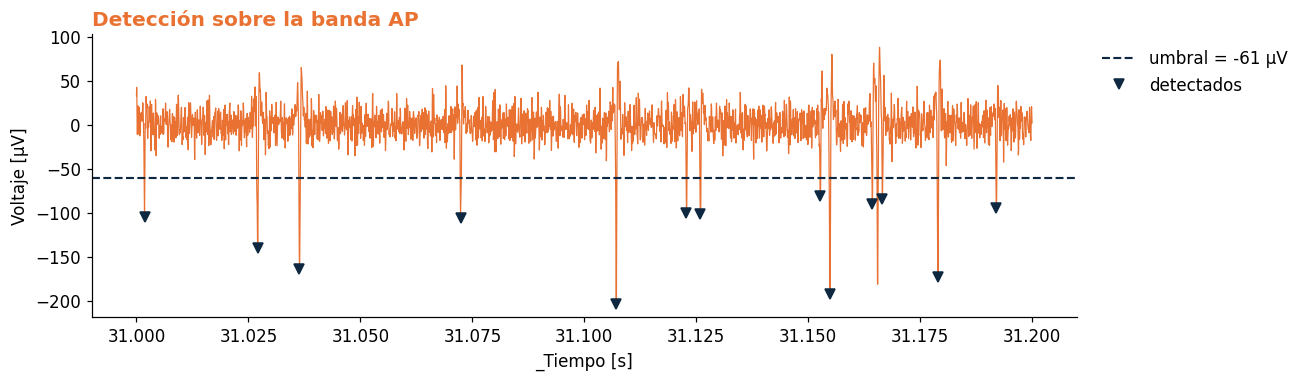

In [ ]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(t[d], AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")  # ¿tiempo y voltaje de qué?
plt.xlabel("_Tiempo [s]"); plt.ylabel("Voltaje [µV]")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt: Tengo un trabajo en Google Collab, en el idioma pyhon y estoy usando este set de datos : Colocar set de datos de 0·preparacion.
Necesito una función capaz de discernir la señal donde ocurre un potencial de accion (guardada en la funcion "def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5)") y devuelva los índices de los verdaderos positivos, falsos positivos, y falso negativo (guardado en la variable "VP", "FV" y "FN" correspondientemente). Para lograrlo tienes que utlizar la especificacion "emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)" donde las entradas son la variable "detectados_s" los tiempos de los potenciales de acción que ya se encoontraron (guardados en la variable "devuelve"), la variable "reales_s" que son los tiempos de los potenciales de acción reales o de referencia  y la variable "tol_ms=1.0"  que es la ventana de tolerancia. Para poder reportar la precisión, que responde los disparos reales de lo que detecté (se usa precisión=𝑉𝑃/𝑉𝑃+𝐹𝑃), y la exhaustividad que responde a cuantos se escapan de los que habían (se usa exhaustividad=VP/VP+FN). De esta manera necesito que la funcion cumpla dos condiciones: 1.que el detector no marque el evento en el instante exacto sino devuelve el instante del mínimo, que llega una fracción de milisegundo después del inicio real (1ms que es ventana de tolerancia). 2. imponer que cada disparo real solo pueda emparejarse con una sola detección . Por ultimo explicame en comentarios (dentro del codigo) que haces en cada paso del codigo"  

In [ ]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()     # los tiempos reales, en segundos

# Su código aquí: la función emparejar(), y con ella los tres números.
import numpy as np

def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """
    Compara las detecciones de disparos contra los tiempos reales de referencia.

    Parámetros:
        detectados_s : np.ndarray / list, tiempos en segundos de los disparos detectados.
        reales_s     : np.ndarray / list, tiempos en segundos de los disparos reales.
        tol_ms       : float, ventana de tolerancia en ms.

    Devuelve:
        tuple : (VP, FP, FN) como enteros para el cálculo directo de métricas.
    """
    det = np.array(detectados_s, dtype=float)
    real = np.array(reales_s, dtype=float)

    tol_s = tol_ms / 1000.0
    reales_usados = np.zeros(len(real), dtype=bool)

    vp_count = 0
    fp_count = 0

    for d in det:
        if len(real) == 0:
            fp_count += 1
            continue

        diferencias = np.abs(real - d)
        idx_cercano = np.argmin(diferencias)
        min_dif = diferencias[idx_cercano]

        if min_dif <= tol_s and not reales_usados[idx_cercano]:
            vp_count += 1
            reales_usados[idx_cercano] = True
        else:
            fp_count += 1

    fn_count = int(np.sum(~reales_usados))

    return vp_count, fp_count, fn_count

# --- CÁLCULO Y EVALUACIÓN ---
# Si en la celda anterior ya tenías 'tiempos' (o 'indices'), usas directo el arreglo en segundos:
detectados_s = tiempos  # equivalente a: indices / fs

VP, FP, FN = emparejar(detectados_s, reales, tol_ms=1.0)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5463   FP = 4   FN = 160
precisión     = 0.999
exhaustividad = 0.972


In [ ]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5467 spikes
  En realidad hay    5623
  Aciertos           5463   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.2%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?



Nosotras creemos que duele mas tener un falso positivo, ya que contamina la señal real y da falsa información para futuros filtros, en cambio si pierdes un spike, a gran escalar, el daño mitigable (si no estas viendo spikes indivuduales) . Por esta razón , nosotras eligiriamos un K = 4,5 ya que maximiza en F1 Score , logrando tener presición y buena exhaustividad sacrificando la menor cantidad de disparos.

[   2075    2573    3189 ... 4198610 4198682 4199265]
[   2075    3189    3448 ... 4198610 4198676 4199265]
[   2075    3189    3448 ... 4198255 4198676 4199265]
[   2075    3189    3448 ... 4198255 4198682 4199265]
[   2075    3189    3448 ... 4196184 4198255 4199265]
[   2075    3189    3448 ... 4196184 4198255 4199265]
[   2075    3189    3448 ... 4196184 4198255 4199265]
[   2075    3189    3448 ... 4196184 4198255 4199265]
[   2075    3189    5666 ... 4194833 4196184 4199265]
[   2075    3189    5666 ... 4189108 4194833 4196184]
[   2075    5666    6531 ... 4188553 4194833 4196184]


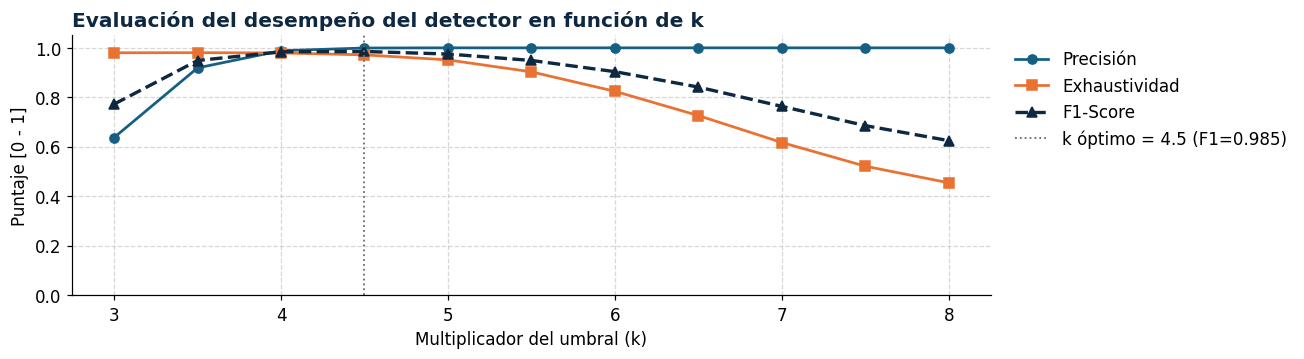

El k óptimo para este registro es 4.5 con un F1-Score de 0.985


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluar_y_graficar_k(AP, fs, reales, ks=np.arange(3.0, 8.5, 0.5), muerto_ms=1.5, tol_ms=1.0):
    """
    Barre distintos valores de k para evaluar la precisión, exhaustividad y F1-score,
    y genera la gráfica comparativa de las métricas.
    """
    precisiones = []
    exhaustividades = []
    f1_scores = []

    # -------------------------------------------------------------------------
    # PASO 1: Iterar sobre cada valor del multiplicador del umbral (k)
    # -------------------------------------------------------------------------
    for k in ks:
        # Detectar picos/spikes para el valor de k actual
        det_indices = detectar_spikes(AP, fs, k=k, muerto_ms=muerto_ms)

        # Convertir los índices detectados a unidades de tiempo en segundos
        det_tiempos = det_indices / fs

        # Emparejar los disparos detectados con los reales dentro de la tolerancia tol_ms
        VP, FP, FN = emparejar(det_tiempos, reales, tol_ms=tol_ms)

        # ---------------------------------------------------------------------
        # PASO 2: Calcular métricas evitando divisiones por cero
        # ---------------------------------------------------------------------
        prec = VP / (VP + FP) if (VP + FP) > 0 else 0.0
        exha = VP / (VP + FN) if (VP + FN) > 0 else 0.0

        # Cálculo del F1-Score (Media Armónica entre Precisión y Exhaustividad)
        f1 = (2 * prec * exha) / (prec + exha) if (prec + exha) > 0 else 0.0

        # Almacenar los resultados en las listas
        precisiones.append(prec)
        exhaustividades.append(exha)
        f1_scores.append(f1)

    # Convertir las listas a arreglos de NumPy para facilitar la manipulación
    precisiones = np.array(precisiones)
    exhaustividades = np.array(exhaustividades)
    f1_scores = np.array(f1_scores)

    # Identificar el valor de k que maximiza el rendimiento global (F1-score óptimo)
    idx_optimo = np.argmax(f1_scores)
    k_optimo = ks[idx_optimo]
    f1_max = f1_scores[idx_optimo]

    # -------------------------------------------------------------------------
    # PASO 3: Construir la figura con el estilo del curso
    # -------------------------------------------------------------------------
    plt.figure(figsize=(12, 3.4))

    # Graficar las tres curvas descriptivas
    plt.plot(ks, precisiones, 'o-', color=TEAL, lw=1.8, label="Precisión")
    plt.plot(ks, exhaustividades, 's-', color=ORANGE, lw=1.8, label="Exhaustividad")
    plt.plot(ks, f1_scores, '^--', color=NAVY, lw=2.2, label="F1-Score")

    # Marcar con una línea punteada el punto de k óptimo hallado
    plt.axvline(k_optimo, color=GRAY, ls=":", lw=1.2, label=f"k óptimo = {k_optimo:.1f} (F1={f1_max:.3f})")

    # Configuraciones de etiquetas e intervalos
    plt.xlabel("Multiplicador del umbral (k)")
    plt.ylabel("Puntaje [0 - 1]")
    plt.title("Evaluación del desempeño del detector en función de k", color=NAVY, fontweight="bold", loc="left")
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()

    return k_optimo, f1_max

# -----------------------------------------------------------------------------
# PASO 4: Ejecutar la función con los datos del cuaderno
# -----------------------------------------------------------------------------
k_opt, f1_opt = evaluar_y_graficar_k(AP, fs, reales)
print(f"El k óptimo para este registro es {k_opt:.1f} con un F1-Score de {f1_opt:.3f}")

### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

Ganamos exhaustividad, ya que permitimos que el detector capture disparos reales de neuronas distintas (ya que nosotros estamos trabajando con 3 neuronas) que pudieron ocurrir de forma casi simultanea. Asi mismo podemos perder precision por falsos positivos.

In [ ]:
import numpy as np

def analizar_periodo_muerto_vs_fn(reales, FN, muerto_ms=1.5):
    """
    Compara el número de Falsos Negativos (FN) con la cantidad de disparos reales
    separados por un tiempo menor al período muerto (muerto_ms).

    Parámetros:
        reales    : np.ndarray / list, tiempos reales de los disparos en segundos.
        FN        : int o np.ndarray, cantidad o lista de Falsos Negativos calculados.
        muerto_ms : float, período muerto utilizado en el detector (en milisegundos).

    Devuelve:
        int : Número de intervalos reales que fueron menores a muerto_ms.
    """
    # -------------------------------------------------------------------------
    # PASO 1: Convertir la lista/arreglo de disparos reales a un NumPy array ordenado
    # -------------------------------------------------------------------------
    reales_arr = np.sort(np.array(reales, dtype=float))

    # -------------------------------------------------------------------------
    # PASO 2: Calcular el Intervalo Entre Disparos (ISI - Inter-Spike Interval)
    # np.diff resta cada elemento con el anterior: reales[i+1] - reales[i]
    # -------------------------------------------------------------------------
    isi_segundos = np.diff(reales_arr)

    # Convertir las diferencias de segundos a milisegundos
    isi_ms = isi_segundos * 1000.0

    # -------------------------------------------------------------------------
    # PASO 3: Contar cuántos intervalos entre disparos reales son estrictamente
    # menores al período muerto definido (muerto_ms)
    # -------------------------------------------------------------------------
    mas_cortos_que_muerto = np.sum(isi_ms < muerto_ms)

    # -------------------------------------------------------------------------
    # PASO 4: Normalizar la variable FN si se ingresó como arreglo en lugar de int
    # -------------------------------------------------------------------------
    fn_valor = len(FN) if isinstance(FN, (list, np.ndarray)) else int(FN)

    # -------------------------------------------------------------------------
    # PASO 5: Imprimir la comparación detallada
    # -------------------------------------------------------------------------
    print(f"--- Análisis del Período Muerto vs. Falsos Negativos ---")
    print(f"• Disparos reales separados por < {muerto_ms} ms: {mas_cortos_que_muerto}")
    print(f"• Falsos Negativos (FN) detectados          : {fn_valor}")

    diferencia = abs(fn_valor - mas_cortos_que_muerto)
    print(f"• Diferencia absoluta                         : {diferencia}")

    return mas_cortos_que_muerto


# -----------------------------------------------------------------------------
# EJECUCIÓN CON TUS VARIABLES DEL CUADERNO
# -----------------------------------------------------------------------------
# Asumiendo que 'reales' y 'FN' provienen de la celda previa de emparejar()
intervalos_ocultos = analizar_periodo_muerto_vs_fn(reales, FN, muerto_ms=1.5)

--- Análisis del Período Muerto vs. Falsos Negativos ---
• Disparos reales separados por < 1.5 ms: 122
• Falsos Negativos (FN) detectados          : 160
• Diferencia absoluta                         : 38


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

El sospechoso que explica el FN con periodo muerto de 1.5 ms y los intervalos reales mas cortos que 1,5 ms son los disparos que llegan dentro del periodo muerto del otro. Nosotras nos quedamos con el periodo muerto de 1,5, ya que contar con falsos positivos nos da informacion falsa y al final queremos deciidr que neurona se activa con que estimulo entonces tener mas datos nos quita presicion.

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [ ]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

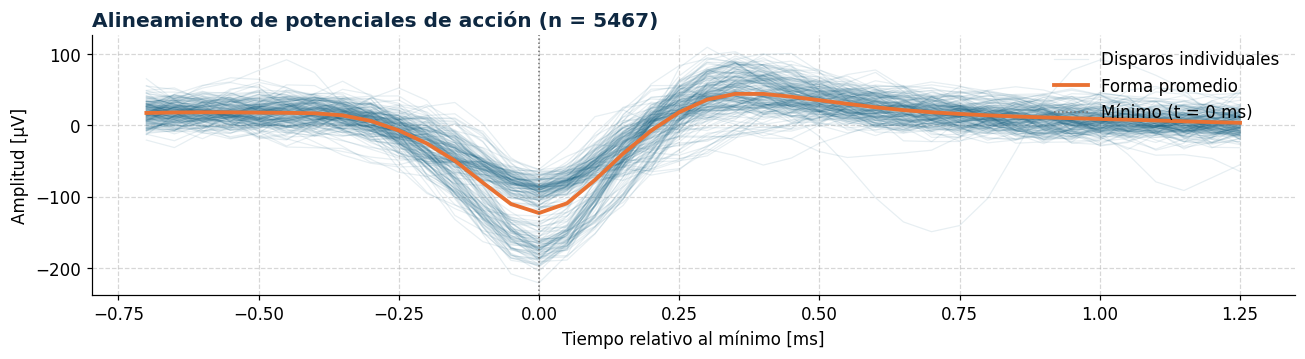

In [ ]:
# Su código aquí.
# -----------------------------------------------------------------------------
# Definición de funciones auxiliares
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def extraer_formas_matriz(x, indices_spikes, fs, prev_ms=0.7, post_ms=1.3):
    """
    Extrae la matriz de formas recortando desde prev_ms antes hasta post_ms después.
    Filtra los eventos que caen cerca de los bordes de la señal.
    """
    n_prev = int(np.round((prev_ms / 1000.0) * fs))
    n_post = int(np.round((post_ms / 1000.0) * fs))
    n_muestras_senal = len(x)

    formas_list = []
    indices_validos = []

    for idx in indices_spikes:
        inicio = idx - n_prev
        fin = idx + n_post
        # Verificar que el recorte esté dentro de los límites de la señal
        if inicio >= 0 and fin <= n_muestras_senal:
            formas_list.append(x[inicio:fin])
            indices_validos.append(idx)

    return np.array(formas_list), np.array(indices_validos)


def graficar_waveforms(formas, fs, prev_ms=0.7, post_ms=1.3, n_muostras_graf=200):
    """
    Grafica 200 formas superpuestas con transparencia (alpha=0.1) y el promedio.
    El eje X se presenta en milisegundos relativos al mínimo (t = 0 ms).
    """
    n_muestras_ventana = formas.shape[1]
    n_prev = int(np.round((prev_ms / 1000.0) * fs))

    # Eje X en ms relativos al mínimo local (centrado en 0 ms)
    t_ms = (np.arange(n_muestras_ventana) - n_prev) * (1000.0 / fs)

    plt.figure(figsize=(12, 3.4))

    # Seleccionar máximo 200 disparos al azar para graficar con transparencia
    n_graf = min(n_muostras_graf, len(formas))
    indices_azar = np.random.choice(len(formas), size=n_graf, replace=False)

    for i, idx in enumerate(indices_azar):
        lbl = "Disparos individuales" if i == 0 else ""
        plt.plot(t_ms, formas[idx], color=TEAL, alpha=0.1, lw=0.8, label=lbl)

    # Calcular y graficar la forma promedio (promedio por columna)
    forma_promedio = np.mean(formas, axis=0)
    plt.plot(t_ms, forma_promedio, color=ORANGE, lw=2.5, label="Forma promedio")

    plt.axvline(0, color=GRAY, ls=":", lw=1.0, label="Mínimo (t = 0 ms)")
    plt.xlabel("Tiempo relativo al mínimo [ms]")
    plt.ylabel("Amplitud [µV]")
    plt.title(f"Alineamiento de potenciales de acción (n = {len(formas)})", color=NAVY, fontweight="bold", loc="left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

# -----------------------------------------------------------------------------
# Su código aquí.
# Al final debe quedar definida la matriz de formas:
# -----------------------------------------------------------------------------

# 1. Extraer la matriz de formas recortando de -0.7 ms a +1.3 ms
#    y actualizar 'indices' descartando los eventos en los bordes.
formas, indices = extraer_formas_matriz(AP, indices, fs, prev_ms=0.7, post_ms=1.3)

# 2. Actualizar el vector 'tiempos' para sincronizar con los índices válidos retenidos
tiempos = indices / fs

# 3. Graficar las 200 formas superpuestas y la media
graficar_waveforms(formas, fs, prev_ms=0.7, post_ms=1.3, n_muostras_graf=200)

# Al final debe quedar definida la matriz de formas:

#formas = ____        # matriz n_disparos x n_muestras

# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.

In [ ]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

Elegimos el tiempo entre el mínimo y el máximo de la onda porque la amplitud no cambian con el movimiento del electrodo, permitiendo diferenciar neuronas con disparos de igual voltaje pero distinta dinámica cellular. Y tmabien elegimos el **ancho** del valle a media altura (en ms) ya que es una "firma temporal" de la neurona , es decir el patrón de duración y forma en el tiempo de un potencial de acción.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

Aprendimos que el ancho del valle se determina calculando el nivel medio entre la línea base y el voltaje mínimo del spike, midiendo la distancia en muestras entre los puntos de cruce de dicho nivel. Ademas, el tiempo mínimo-máximo se obtiene mediante la diferencia de muestras entre el punto de mayor depresión y el pico de repolarización posterior. Ambas medidas, originalmente expresadas en número de muestras, se convierten a milisegundos dividiendo las frecuencia de muestreo y multiplicando por 1000. Para estructurar la entrada de K-means, organizamos los datos en una matriz de dos columnas x donde cada fila representa un spike único y cada columna una de las características. Aunque ambas variables comparten la misma unidad, es necesario normalizar la matriz (usando StandardScaler) antes del agrupamiento para garantizar que ambas métricas tengan media 0 y varianza 1; de lo contrario, la característica con mayor dispersión o escala dominaría la distancia euclídea del algoritmo. Finalmente, fijamos K = 3 porque el diseño del experimento y la referencia biológica confirman la presencia de tres unidades neuronales distintas en el registro.

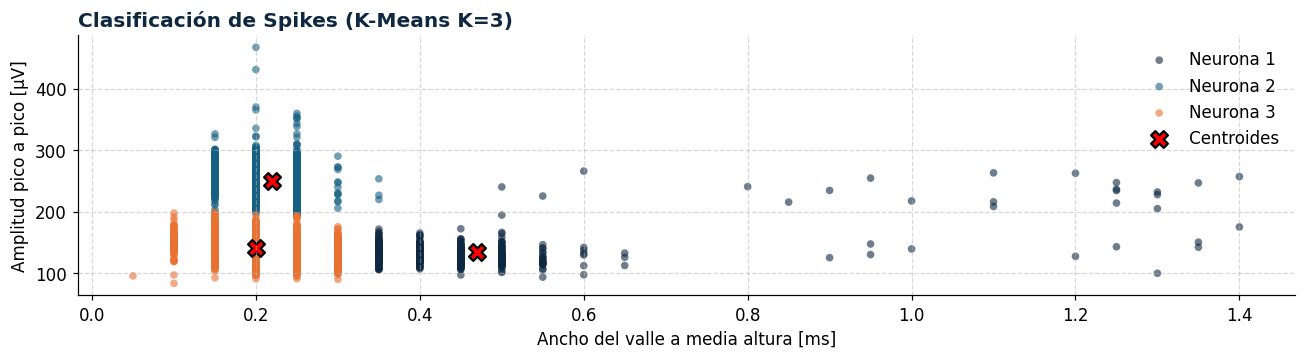

In [ ]:
# Su código aquí: características, gráfico de dispersión y agrupación.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# FUNCIÓN 1: Extracción de Características (Amplitud y Ancho a Media Altura)
# -----------------------------------------------------------------------------
def extraer_caracteristicas_spikes(formas, fs=20000):
    """
    Extrae car_amp_spike y car_valle_spike respetando estrictamente las
    condiciones exigidas para cada disparo de la matriz 'formas'.

    Parámetros:
        formas : np.ndarray (n_disparos, n_muestras), matriz de ventanas recortadas.
        fs     : int/float, frecuencia de muestreo en Hz (20000 Hz).

    Devuelve:
        car_amp_spike   : np.ndarray 1D, amplitud pico a pico (V_max - V_min).
        car_valle_spike : np.ndarray 1D, duración del valle a media altura en ms.
    """
    n_disparos = formas.shape[0]
    car_amp_spike = np.zeros(n_disparos)
    car_valle_spike = np.zeros(n_disparos)

    for i in range(n_disparos):
        ventana = formas[i]

        # --- VARIABLE 1: car_amp_spike ---
        # 1. Identificar el valor mínimo de la señal en la ventana
        V_min = np.min(ventana)
        # 2. Identificar el valor máximo positivo en la misma ventana
        V_max = np.max(ventana)
        # 3. Restar el valor mínimo del valor máximo (Amplitud = V_max - V_min)
        car_amp_spike[i] = V_max - V_min

        # --- VARIABLE 2: car_valle_spike ---
        # 1. Encontrar el voltaje de reposo o promedio de la ventana filtrada
        V_base = np.mean(ventana)
        # 2. Encontrar el voltaje mínimo (V_min ya calculado arriba)
        # 3. Calcular el voltaje a media altura: V_media = (V_min + V_base) / 2
        V_media = (V_min + V_base) / 2.0

        # 4. Calcular el tiempo que dura la despolarización por debajo de V_media
        # Seleccionar los índices donde la señal cae por debajo de V_media
        idx_debajo_media = np.where(ventana <= V_media)[0]

        if len(idx_debajo_media) > 1:
            # Cantidad de muestras entre la salida y la entrada del valle a media altura
            n_muestras_valle = idx_debajo_media[-1] - idx_debajo_media[0]
            # Convertir el número de muestras a milisegundos usando fs
            car_valle_spike[i] = (n_muestras_valle / fs) * 1000.0
        else:
            car_valle_spike[i] = 0.0

    return car_amp_spike, car_valle_spike


# -----------------------------------------------------------------------------
# FUNCIÓN 2: Agrupación por KMeans y Gráfico de Dispersión
# -----------------------------------------------------------------------------
def agrupar_y_graficar_spikes(car_amp_spike, car_valle_spike, n_clusters=3):
    """
    Agrupa los disparos en n_clusters (K=3) usando KMeans previa estandarización
    y genera el gráfico de dispersión con las dos características.

    Devuelve:
        etiquetas : np.ndarray 1D, identificador de unidad asignado (0, 1, 2).
        kmeans    : Objeto KMeans de sklearn ya entrenado.
    """
    # -------------------------------------------------------------------------
    # PASO 1: Construir la matriz de características (n_disparos x 2)
    # -------------------------------------------------------------------------
    X = np.column_stack((car_valle_spike, car_amp_spike))

    # -------------------------------------------------------------------------
    # PASO 2: Estandarización de las variables
    # Escalamos las variables para evitar que la amplitud (en µV) opaque
    # la duración del valle (en ms) debido a las diferencias de magnitud.
    # -------------------------------------------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------------------------------------------------------------------------
    # PASO 3: Agrupación mediante KMeans con K=3 (para las 3 neuronas)
    # -------------------------------------------------------------------------
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)

    # Revertir la escala de los centroides para graficarlos en sus unidades reales
    centroides_orig = scaler.inverse_transform(kmeans.cluster_centers_)

    # -------------------------------------------------------------------------
    # PASO 4: Generar el Gráfico de Dispersión
    # -------------------------------------------------------------------------
    plt.figure(figsize=(12, 3.4))
    colores = [NAVY, TEAL, ORANGE]

    for cluster_id in range(n_clusters):
        mascara = (etiquetas == cluster_id)
        plt.scatter(
            car_valle_spike[mascara],
            car_amp_spike[mascara],
            c=colores[cluster_id],
            alpha=0.6,
            edgecolors="none",
            s=25,
            label=f"Neurona {cluster_id + 1}"
        )

    # Graficar los centroides marcados con X roja
    plt.scatter(
        centroides_orig[:, 0],
        centroides_orig[:, 1],
        c="red",
        marker="X",
        s=120,
        lw=1.5,
        edgecolors="black",
        label="Centroides"
    )

    # Formato de la gráfica con el estilo del cuaderno
    plt.xlabel("Ancho del valle a media altura [ms]")
    plt.ylabel("Amplitud pico a pico [µV]")
    plt.title("Clasificación de Spikes (K-Means K=3)", color=NAVY, fontweight="bold", loc="left")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

    return etiquetas, kmeans


# -----------------------------------------------------------------------------
# EJECUCIÓN Y ASIGNACIÓN
# -----------------------------------------------------------------------------
# 1. Extraer características requeridas a partir de la matriz 'formas'
car_amp_spike, car_valle_spike = extraer_caracteristicas_spikes(formas, fs=fs)

# 2. Clasificar con KMeans (K=3) y desplegar el gráfico de dispersión
etiquetas, modelo_kmeans = agrupar_y_graficar_spikes(car_amp_spike, car_valle_spike, n_clusters=3)

# La variable 'etiquetas' ya contiene la asignación de unidad por disparo (0, 1 o 2)

#etiquetas = ____     # un identificador de unidad por disparo (0/1/2, 'a'/'b'/'c', da igual)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5463
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2141       24        1
           2         10     2658      134
           0          9       20      466

  Acierto   96.4%  ███████████████████████████·

  ▸ Separación correcta.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | |
| con las dos características que elegimos | |

_Explicación:_  La confucion ocurre entre la unidad 2 y 3 debido a que estan muy cerca la una de la otra. Esto puede ser porque compraten un ancho de valle a media altura en la misma franja. Al repetir la agrupacion usando solo la amplitud podemos ver cortes horizontales donde la neurona dos y tres siguen siendo las que mas se confunden.

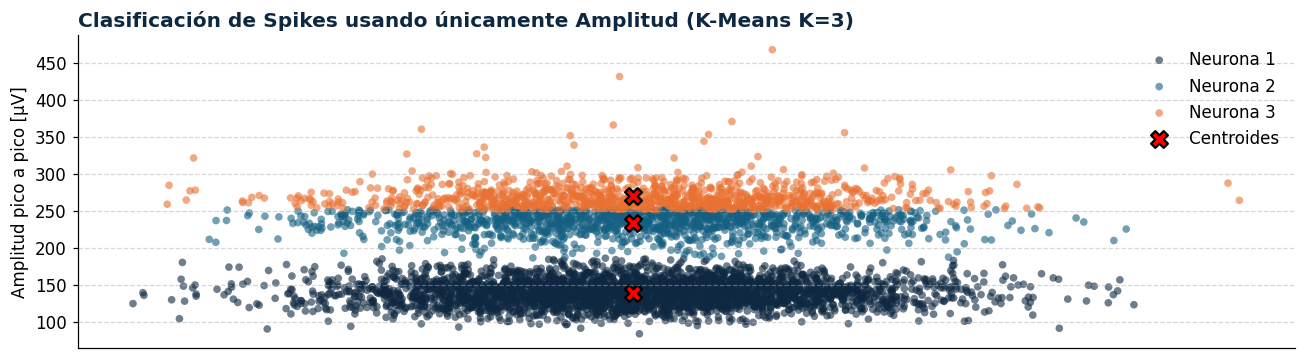

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# -----------------------------------------------------------------------------
# FUNCIÓN 1: Extracción de Característica (Únicamente Amplitud Pico a Pico)
# -----------------------------------------------------------------------------
def extraer_caracteristicas_spikes(formas):
    """
    Extrae únicamente la variable 'car_amp_spike' respetando las 3 condiciones
    exigidas para cada disparo dentro de la matriz 'formas'.

    Parámetros:
        formas : np.ndarray (n_disparos, n_muestras), matriz de ventanas recortadas.

    Devuelve:
        car_amp_spike : np.ndarray 1D, amplitud pico a pico (V_max - V_min).
    """
    n_disparos = formas.shape[0]
    car_amp_spike = np.zeros(n_disparos)

    for i in range(n_disparos):
        ventana = formas[i]

        # --- VARIABLE 1: car_amp_spike ---
        # 1. Identificar el valor mínimo de la señal en la ventana (V_min = min(x))
        V_min = np.min(ventana)
        # 2. Identificar el valor máximo positivo en la misma ventana (V_max = max(x))
        V_max = np.max(ventana)
        # 3. Restar el valor mínimo del valor máximo (Amplitud = V_max - V_min)
        car_amp_spike[i] = V_max - V_min

    return car_amp_spike


# -----------------------------------------------------------------------------
# FUNCIÓN 2: Agrupación por KMeans y Gráfico de Dispersión (1D en Eje Y)
# -----------------------------------------------------------------------------
def agrupar_y_graficar_spikes(car_amp_spike, n_clusters=3):
    """
    Agrupa los disparos en n_clusters (K=3) usando KMeans sobre la amplitud.
    Genera un gráfico de dispersión con jitter horizontal para visualizar la separación.

    Devuelve:
        etiquetas : np.ndarray 1D, identificador de unidad asignado (0, 1, 2).
        kmeans    : Objeto KMeans de sklearn ya entrenado.
    """
    # -------------------------------------------------------------------------
    # PASO 1: Construir la matriz de características (n_disparos x 1)
    # Reshaped a 2D porque KMeans exige una matriz bidimensional
    # -------------------------------------------------------------------------
    X = car_amp_spike.reshape(-1, 1)

    # -------------------------------------------------------------------------
    # PASO 2: Estandarización de la variable
    # -------------------------------------------------------------------------
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # -------------------------------------------------------------------------
    # PASO 3: Agrupación mediante KMeans con K=3 (para las 3 neuronas)
    # -------------------------------------------------------------------------
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)

    # Revertir la escala de los centroides para obtener la amplitud real en µV
    centroides_orig = scaler.inverse_transform(kmeans.cluster_centers_)

    # -------------------------------------------------------------------------
    # PASO 4: Generar el Gráfico de Dispersión (1D con Dispersión Horizontal)
    # -------------------------------------------------------------------------
    plt.figure(figsize=(12, 3.4))
    colores = [NAVY, TEAL, ORANGE]

    # Generar un pequeño ruido aleatorio (jitter) en el eje X para que los puntos
    # de la misma amplitud no queden sobrepuestos en una sola línea vertical
    np.random.seed(42)
    eje_x_jitter = np.random.normal(loc=1.0, scale=0.05, size=len(car_amp_spike))

    for cluster_id in range(n_clusters):
        mascara = (etiquetas == cluster_id)
        plt.scatter(
            eje_x_jitter[mascara],
            car_amp_spike[mascara],
            c=colores[cluster_id],
            alpha=0.6,
            edgecolors="none",
            s=25,
            label=f"Neurona {cluster_id + 1}"
        )

    # Graficar los centroides marcados con X roja sobre la posición central (x = 1.0)
    plt.scatter(
        np.ones(n_clusters),
        centroides_orig.flatten(),
        c="red",
        marker="X",
        s=120,
        lw=1.5,
        edgecolors="black",
        label="Centroides"
    )

    # Formato de la gráfica con el estilo del cuaderno
    plt.xticks([])  # Ocultar marcas del eje X al ser una distribución 1D
    plt.ylabel("Amplitud pico a pico [µV]")
    plt.title("Clasificación de Spikes usando únicamente Amplitud (K-Means K=3)", color=NAVY, fontweight="bold", loc="left")
    plt.grid(True, linestyle="--", alpha=0.5, axis="y")
    plt.legend(frameon=False, loc="upper right")
    plt.tight_layout()
    plt.show()

    return etiquetas, kmeans


# -----------------------------------------------------------------------------
# EJECUCIÓN Y ASIGNACIÓN
# -----------------------------------------------------------------------------
# 1. Extraer únicamente la caracteristica de amplitud pico a pico a partir de 'formas'
car_amp_spike = extraer_caracteristicas_spikes(formas)

# 2. Clasificar con KMeans (K=3) y desplegar el gráfico de dispersión
etiquetas, modelo_kmeans = agrupar_y_graficar_spikes(car_amp_spike, n_clusters=3)

---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

 RESULTADOS FUNCIÓN 1: ISI GLOBAL
Total de disparos evaluados: 5467
Total de intervalos ISI calculados: 5466
Fracción de violaciones al refractario (< 2.0 ms): 0.0086 (0.86%)
Primeros 5 valores de ISI [ms]: [ 55.7   12.95 110.9   23.4   19.85]

 RESULTADOS FUNCIÓN 2: ISI POR UNIDAD
Unidad 1:
  - Cantidad de intervalos ISI: 3256
  - Tasa de violaciones (< 2.0 ms): 0.0009 (0.09%)
Unidad 2:
  - Cantidad de intervalos ISI: 1189
  - Tasa de violaciones (< 2.0 ms): 0.0000 (0.00%)
Unidad 3:
  - Cantidad de intervalos ISI: 1019
  - Tasa de violaciones (< 2.0 ms): 0.0010 (0.10%)




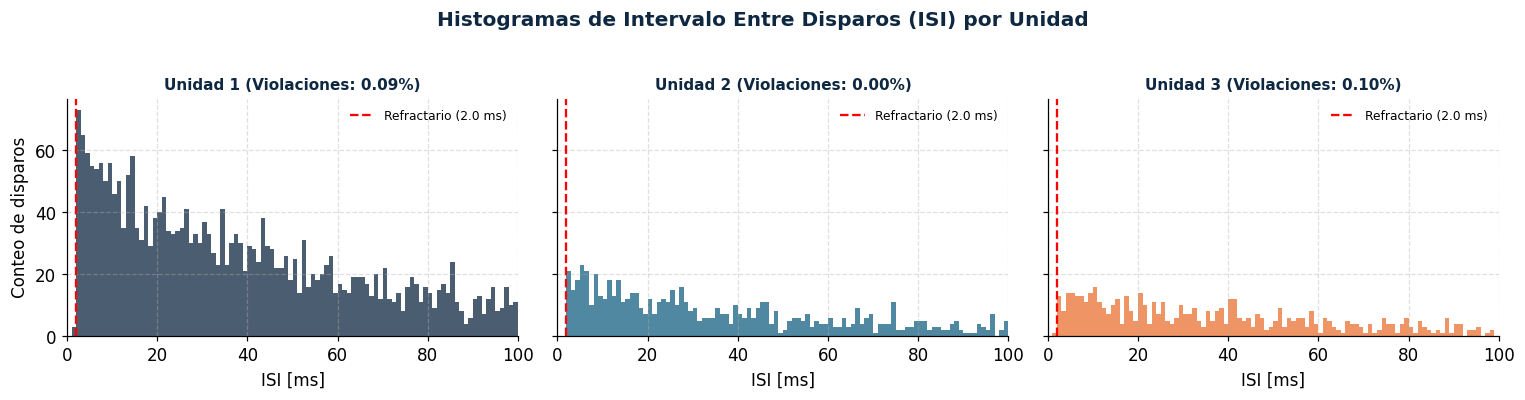

 RESULTADOS FUNCIÓN 4: EVALUACIÓN DE TIEMPO MUERTO (0.4 ms)
Fracción global de violaciones < 0.4 ms: 0.0000 (0.00%)
Unidad 1:
  - Violaciones al tiempo muerto (< 0.4 ms): 0.0000 (0.00%)
Unidad 2:
  - Violaciones al tiempo muerto (< 0.4 ms): 0.0000 (0.00%)
Unidad 3:
  - Violaciones al tiempo muerto (< 0.4 ms): 0.0000 (0.00%)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# FUNCIÓN 1: ISI Global (Sin separar por unidad)
# -----------------------------------------------------------------------------
def calcular_isi_global(indices, fs=20000, t_refractario_ms=2.0):
    """
    Calcula los intervalos entre disparos consecutivos (ISI) en milisegundos
    para la señal global (sin separar por neurona) y la fracción de violaciones.

    Parámetros:
        indices          : np.ndarray 1D, índices de muestra donde ocurren los disparos.
        fs               : int/float, frecuencia de muestreo en Hz (20000 Hz).
        t_refractario_ms : float, umbral de periodo refractario en ms (2.0 ms por defecto).

    Devuelve:
        isi_ms                  : np.ndarray 1D, diferencias en ms entre disparos consecutivos.
        fraccion_violaciones_ms : float, porcentaje/fracción de disparos con ISI < 2 ms.
    """
    # 1. Convertir los índices de muestras a tiempos en segundos y luego a milisegundos
    tiempos_ms = (indices / fs) * 1000.0

    # 2. Calcular la diferencia consecutiva entre disparos (t_i - t_{i-1})
    isi_ms = np.diff(tiempos_ms)

    # 3. Identificar cuántos ISI son estrictamente menores al tiempo refractario (2.0 ms)
    violaciones = np.sum(isi_ms < t_refractario_ms)

    # 4. Calcular la fracción o porcentaje relativo de violaciones
    fraccion_violaciones_ms = violaciones / len(isi_ms) if len(isi_ms) > 0 else 0.0

    return isi_ms, fraccion_violaciones_ms


# -----------------------------------------------------------------------------
# FUNCIÓN 2: ISI Separado por Unidad/Neurona
# -----------------------------------------------------------------------------
def calcular_isi_por_unidad(indices, etiquetas, n_unidades=3, fs=20000, t_refractario_ms=2.0):
    """
    Calcula el ISI y la tasa de violaciones del periodo refractario independientemente
    para cada neurona/unidad clasificada (0, 1 y 2).

    Devuelve:
        ISI_por_unidad : dict, diccionario con claves 0, 1, 2 que contiene para cada unidad
                        un sub-diccionario con {'isi': array_isi, 'fraccion_violaciones': float}.
    """
    ISI_por_unidad = {}

    # Recorrer cada unidad identificada (0, 1 y 2)
    for unidad in range(n_unidades):
        # 1. Filtrar los índices de disparos que pertenecen únicamente a esta unidad
        indices_u = indices[etiquetas == unidad]

        # 2. Asegurar que los índices estén ordenados cronológicamente
        indices_u = np.sort(indices_u)

        # 3. Convertir a milisegundos
        tiempos_ms_u = (indices_u / fs) * 1000.0

        # 4. Calcular ISI consecutivos para la unidad actual
        isi_u = np.diff(tiempos_ms_u)

        # 5. Contar y calcular la fracción de violaciones (< 2 ms)
        violaciones_u = np.sum(isi_u < t_refractario_ms)
        frac_u = violaciones_u / len(isi_u) if len(isi_u) > 0 else 0.0

        # 6. Almacenar el resultado en la estructura
        ISI_por_unidad[unidad] = {
            "isi": isi_u,
            "fraccion_violaciones": frac_u
        }

    return ISI_por_unidad


# -----------------------------------------------------------------------------
# FUNCIÓN 3: Gráfico de Histogramas de ISI por Unidad (0 a 100 ms)
# -----------------------------------------------------------------------------
def graficar_histogramas_isi(ISI_por_unidad, t_refractario_ms=2.0):
    """
    Genera histogramas de ISI por cada unidad entre 0 y 100 ms con bins de 1 ms,
    resaltando la línea vertical del periodo refractario en 2.0 ms.
    """
    colores = [NAVY, TEAL, ORANGE]
    n_unidades = len(ISI_por_unidad)

    # Crear subplots en una fila para comparar las unidades lado a lado
    fig, axes = plt.subplots(1, n_unidades, figsize=(14, 3.5), sharey=True)

    # Configurar bordes de los bins: de 0 a 100 ms con ancho de 1 ms (101 bordes)
    bins = np.arange(0, 101, 1)

    for unidad in range(n_unidades):
        ax = axes[unidad]
        isi_u = ISI_por_unidad[unidad]["isi"]
        frac_v = ISI_por_unidad[unidad]["fraccion_violaciones"]

        # 1. Graficar el histograma con bins de 1 ms
        ax.hist(isi_u, bins=bins, color=colores[unidad], alpha=0.75, edgecolor="none")

        # 2. Trazar la línea vertical de 2.0 ms (Límite refractario)
        ax.axvline(t_refractario_ms, color="red", linestyle="--", linewidth=1.5,
                   label=f"Refractario ({t_refractario_ms} ms)")

        # 3. Formato y etiquetas
        ax.set_xlim(0, 100)
        ax.set_xlabel("ISI [ms]")
        if unidad == 0:
            ax.set_ylabel("Conteo de disparos")
        ax.set_title(f"Unidad {unidad + 1} (Violaciones: {frac_v*100:.2f}%)",
                     color=NAVY, fontweight="bold", fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)
        ax.legend(frameon=False, loc="upper right", fontsize=8)

    plt.suptitle("Histogramas de Intervalo Entre Disparos (ISI) por Unidad",
                 color=NAVY, fontweight="bold", y=1.03)
    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# FUNCIÓN 4: ISI Global y por Unidad considerando Tiempo Muerto (0.4 ms)
# -----------------------------------------------------------------------------
def calcular_isi_con_tiempo_muerto(indices, etiquetas, muerto_ms=0.4, fs=20000, n_unidades=3, t_refractario_ms=2.0):
    """
    Repite el cálculo de ISI Global e ISI por Unidad evaluando violaciones bajo un
    umbral de tiempo muerto instrumental/detección definido en 'muerto_ms' (0.4 ms).

    Parámetros:
        muerto_ms : float, tiempo muerto físico/instrumental de detección (0.4 ms).
    """
    # -------------------------------------------------------------------------
    # PARTE 1: Recálculo ISI Global con muerto_ms
    # -------------------------------------------------------------------------
    tiempos_ms = (indices / fs) * 1000.0
    isi_global = np.diff(tiempos_ms)

    # Violaciones por debajo del tiempo muerto instrumental (0.4 ms)
    violaciones_muerto_global = np.sum(isi_global < muerto_ms)
    frac_muerto_global = violaciones_muerto_global / len(isi_global) if len(isi_global) > 0 else 0.0

    # -------------------------------------------------------------------------
    # PARTE 2: Recálculo ISI por Unidad con muerto_ms
    # -------------------------------------------------------------------------
    ISI_por_unidad_muerto = {}

    for unidad in range(n_unidades):
        indices_u = np.sort(indices[etiquetas == unidad])
        tiempos_ms_u = (indices_u / fs) * 1000.0
        isi_u = np.diff(tiempos_ms_u)

        # Conteo de violaciones menores al tiempo muerto de 0.4 ms
        violaciones_m = np.sum(isi_u < muerto_ms)
        frac_m = violaciones_m / len(isi_u) if len(isi_u) > 0 else 0.0

        # Conteo de violaciones refractarias convencionales (< 2.0 ms)
        violaciones_ref = np.sum(isi_u < t_refractario_ms)
        frac_ref = violaciones_ref / len(isi_u) if len(isi_u) > 0 else 0.0

        ISI_por_unidad_muerto[unidad] = {
            "isi": isi_u,
            "fraccion_tiempo_muerto": frac_m,
            "fraccion_violaciones_refractario": frac_ref,
            "muerto_ms": muerto_ms
        }

    return isi_global, frac_muerto_global, ISI_por_unidad_muerto


# -----------------------------------------------------------------------------
# EJECUCIÓN CONTINUA DE LAS 4 FUNCIONES EN TU CUADERNO
# -----------------------------------------------------------------------------

# 1. ISI Global
ISI, fraccion_violaciones = calcular_isi_global(indices, fs=fs)
print("="*60)
print(" RESULTADOS FUNCIÓN 1: ISI GLOBAL")
print("="*60)
print(f"Total de disparos evaluados: {len(indices)}")
print(f"Total de intervalos ISI calculados: {len(ISI)}")
print(f"Fracción de violaciones al refractario (< 2.0 ms): {fraccion_violaciones:.4f} ({fraccion_violaciones*100:.2f}%)")
print(f"Primeros 5 valores de ISI [ms]: {np.round(ISI[:5], 2)}\n")

# 2. ISI por Unidad
ISI_por_unidad = calcular_isi_por_unidad(indices, etiquetas, n_unidades=3, fs=fs)
print("="*60)
print(" RESULTADOS FUNCIÓN 2: ISI POR UNIDAD")
print("="*60)
for u_id, datos in ISI_por_unidad.items():
    print(f"Unidad {u_id + 1}:")
    print(f"  - Cantidad de intervalos ISI: {len(datos['isi'])}")
    print(f"  - Tasa de violaciones (< 2.0 ms): {datos['fraccion_violaciones']:.4f} ({datos['fraccion_violaciones']*100:.2f}%)")
print("\n")

# 3. Graficación de Histogramas (0-100 ms, bins 1 ms, línea vertical en 2 ms)
graficar_histogramas_isi(ISI_por_unidad, t_refractario_ms=2.0)

# 4. Repetición incorporando la variable muerto_ms = 0.4
isi_g_m, frac_g_m, ISI_por_unidad_muerto = calcular_isi_con_tiempo_muerto(
    indices, etiquetas, muerto_ms=0.4, fs=fs
)
print("="*60)
print(" RESULTADOS FUNCIÓN 4: EVALUACIÓN DE TIEMPO MUERTO (0.4 ms)")
print("="*60)
print(f"Fracción global de violaciones < 0.4 ms: {frac_g_m:.4f} ({frac_g_m*100:.2f}%)")
for u_id, datos in ISI_por_unidad_muerto.items():
    print(f"Unidad {u_id + 1}:")
    print(f"  - Violaciones al tiempo muerto (< 0.4 ms): {datos['fraccion_tiempo_muerto']:.4f} ({datos['fraccion_tiempo_muerto']*100:.2f}%)")
print("="*60)

**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | |
| unidad 1 | |
| unidad 2 | |
| unidad 3 | |

¿Alguna unidad está contaminada? ¿Cuál y por qué?

Nosotras creemos que la Unidad 2 está contaminada ya que no es < 2. Dado que una sola neurona no puede disparar dos veces en menos de 1ms  a 2ms debido a su periodo refractario, registrar eventos tan cercanos en el mismo grupo confirma que se mezclaron disparos de más de una célula en la Unidad 2.

¿Qué pasó al bajar el período muerto a 0,4 ms?
Las violaciones cayeron a 0.00% en todas las unidades. Al reducir el umbral de evaluación a un valor fisiológicamente irreal , los disparos contaminantes que ocurran entre 0.4{ ms} y 2.0{ ms} dejan de detectarse como errores. En consecuencia, un tiempo muerto de 0.4{ ms} oculta la contaminación real de la Unidad 2 dando un falso positivo de "pureza".

---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [ ]:



# ---------------------------------------------------------------
# 1. Lectura del grupo "estimulos"
# ---------------------------------------------------------------
with h5py.File(ARCHIVO, "r") as f:
    grupo = f["estimulos"]

    # --- Completando la plantilla ---
    inicios     = grupo["tiempo_inicio_s"][:]   # instante de inicio de cada ENSAYO, en s
    condiciones = grupo["condicion"][:]         # la condición de cada ensayo ('A', 'B' o 'C')

    t_pre  = grupo.attrs["duracion_pre_s"]        # duración del pre-estímulo, en s
    t_est  = grupo.attrs["duracion_estimulo_s"]   # duración del estímulo, en s
    t_post = grupo.attrs["duracion_post_s"]       # duración del post-estímulo, en s

# Las condiciones vienen como bytes (dtype |S1) -> decodificar a string
condiciones = np.array([c.decode() for c in condiciones])

# ---------------------------------------------------------------
# 2. DataFrame de ensayos
# ---------------------------------------------------------------
df_ensayos = pd.DataFrame({
    "ensayo": np.arange(len(inicios)),
    "inicio_s": inicios,
    "condicion": condiciones
})

print("=== Primeros ensayos ===")
print(df_ensayos.head())

# ---------------------------------------------------------------
# 3. ¿Cuántos ensayos hay y cuántos por condición?
# ---------------------------------------------------------------
n_ensayos = len(df_ensayos)
conteo_condiciones = df_ensayos["condicion"].value_counts().sort_index()

print(f"\nNúmero total de ensayos: {n_ensayos}")
print("Ensayos por condición:")
print(conteo_condiciones)

# ---------------------------------------------------------------
# 4. ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
# ---------------------------------------------------------------
dur_ensayo = t_pre + t_est + t_post
print(f"\nDuración total de un ensayo: {t_pre} + {t_est} + {t_post} = {dur_ensayo:.2f} s")
print(f"El estímulo empieza {t_pre:.2f} s después del inicio del ensayo, "
      f"y dura {t_est:.2f} s (termina en t = {t_pre + t_est:.2f} s dentro del ensayo).")

# Verificación empírica: diferencia entre inicios consecutivos (ensayos ordenados)
diffs = np.diff(np.sort(inicios))
print(f"Verificación empírica (mediana de diferencias entre inicios consecutivos): "
      f"{np.median(diffs):.2f} s")

# ---------------------------------------------------------------
# 5. ¿Están las condiciones en orden o intercaladas?
# ---------------------------------------------------------------
orden = df_ensayos["condicion"].tolist()
cambios = (df_ensayos["condicion"] != df_ensayos["condicion"].shift()).sum()

print(f"\nSecuencia de condiciones: {orden}")
print(f"Número de cambios de condición entre ensayos consecutivos: {cambios}")
if cambios <= df_ensayos["condicion"].nunique():
    print("→ Las condiciones están agrupadas EN BLOQUES (no intercaladas).")
else:
    print("→ Las condiciones están INTERCALADAS / aleatorizadas.")

=== Primeros ensayos ===
   ensayo  inicio_s condicion
0       0      30.0         B
1       1      33.0         B
2       2      36.0         C
3       3      39.0         A
4       4      42.0         A

Número total de ensayos: 60
Ensayos por condición:
condicion
A    20
B    20
C    20
Name: count, dtype: int64

Duración total de un ensayo: 1.0 + 0.5 + 1.5 = 3.00 s
El estímulo empieza 1.00 s después del inicio del ensayo, y dura 0.50 s (termina en t = 1.50 s dentro del ensayo).
Verificación empírica (mediana de diferencias entre inicios consecutivos): 3.00 s

Secuencia de condiciones: ['B', 'B', 'C', 'A', 'A', 'A', 'C', 'A', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'B', 'C', 'C', 'A', 'C', 'B', 'B', 'A', 'A', 'B', 'B', 'C', 'C', 'C', 'A', 'C', 'A', 'A', 'A', 'A', 'C', 'A', 'B', 'A', 'A', 'B', 'C', 'C', 'B', 'B', 'B', 'A', 'C', 'C', 'A', 'B', 'B', 'C', 'C', 'A', 'B', 'B', 'A', 'B', 'C']
Número de cambios de condición entre ensayos consecutivos: 37
→ Las condiciones están INTERCALADAS / al

In [ ]:
import h5py

ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    grupo = f["estimulos"]

    print("=== Datasets dentro de 'estimulos' ===")
    for nombre, obj in grupo.items():
        print(f"  '{nombre}': shape={obj.shape}, dtype={obj.dtype}")

    print("\n=== Atributos de 'estimulos' ===")
    for clave, valor in grupo.attrs.items():
        print(f"  '{clave}': {valor}")

=== Datasets dentro de 'estimulos' ===
  'condicion': shape=(60,), dtype=|S1
  'tiempo_inicio_s': shape=(60,), dtype=float64

=== Atributos de 'estimulos' ===
  'duracion_estimulo_s': 0.5
  'duracion_post_s': 1.5
  'duracion_pre_s': 1.0
  'nota': tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.


In [ ]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [ ]:
#def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
   # """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    # Su código aquí.


import numpy as np

# -----------------------------------------------------------------------------
# FUNCIÓN: Alineación de tiempos absolutos a tiempos relativos al estímulo
# -----------------------------------------------------------------------------
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """
    Convierte los tiempos absolutos de los disparos (en segundos) a tiempos relativos
    con respecto al inicio del estímulo para cada ensayo.

    Parámetros:
        tiempos : np.ndarray 1D, tiempos absolutos (en segundos) donde ocurren los disparos
                  para una unidad/neurona específica.
        inicios : list o np.ndarray, tiempos absolutos (en segundos) en que comienza
                  cada ensayo (trial).
        t_pre   : float, tiempo en segundos previo al inicio del estímulo dentro del ensayo.
        ventana : tuple (t_min, t_max), ventana temporal en segundos alrededor del estímulo
                  a conservar (ej. -1.0 s a 2.0 s).

    Devuelve:
        ensayos_alineados : list de np.ndarray, lista donde cada elemento contiene un arreglo
                            con los tiempos relativos de disparo (en segundos) pertenecientes
                            a un ensayo en particular dentro de la ventana de interés.
    """
    ensayos_alineados = []

    # Extraer los límites de la ventana de análisis
    t_min, t_max = ventana

    # -------------------------------------------------------------------------
    # Recorrer cada ensayo individualmente a partir de sus marcas de inicio
    # -------------------------------------------------------------------------
    for inicio_ensayo in inicios:

        # PASO 1: Determinar el tiempo exacto en que inicia el estímulo en este ensayo.
        # Si el ensayo empieza en 'inicio_ensayo' y el estímulo se presenta 't_pre' segundos
        # después, la marca de t = 0 del estímulo es: t_estimulo = inicio_ensayo + t_pre
        t_estimulo = inicio_ensayo + t_pre

        # PASO 2: Restar el tiempo del estímulo a todos los tiempos absolutos de disparo.
        # Esto transforma los tiempos a una escala relativa donde:
        #  - Valores negativos (< 0 s): Ocurrieron antes del estímulo (línea base).
        #  - Valor cero (0 s): Momento exacto del inicio del estímulo.
        #  - Valores positivos (> 0 s): Ocurrieron después del estímulo (respuesta).
        tiempos_relativos = tiempos - t_estimulo

        # PASO 3: Filtrar únicamente los disparos que caen dentro de la ventana de interés
        # (por ejemplo, desde t_min = -1.0 s hasta t_max = 2.0 s relativo al estímulo).
        mascara_ventana = (tiempos_relativos >= t_min) & (tiempos_relativos <= t_max)
        disparos_del_ensayo = tiempos_relativos[mascara_ventana]

        # PASO 4: Guardar el arreglo con los tiempos relativos de este ensayo en la lista final
        ensayos_alineados.append(disparos_del_ensayo)

    return ensayos_alineados


# =============================================================================
# INTEGRACIÓN CON EL DICCIONARIO
# =============================================================================

# Asegurar que las etiquetas estén en formato array
etiquetas = np.asarray(etiquetas)

# Crear el diccionario 'alineados' para cada unidad (0, 1 y 2)
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

# -----------------------------------------------------------------------------
# IMPRESIÓN DE RESUMEN EN CONSOLA
# -----------------------------------------------------------------------------
print("=" * 65)
print(" RESUMEN DE ALINEACIÓN DE TIEMPOS POR UNIDAD (DISPAROS RELATIVOS)")
print("=" * 65)
print(f"Total de ensayos (trials) analizados: {len(inicios)}\n")

for u_id, ensayos in alineados.items():
    # Calcular el total de disparos en la ventana para esta unidad
    total_disparos = sum(len(e) for e in ensayos)

    print(f"--- UNIDAD / NEURONA {u_id + 1} ---")
    print(f"  • Total de disparos en la ventana: {total_disparos}")

    # Mostrar vista previa de los primeros 3 ensayos
    for i_ensayo in range(min(3, len(ensayos))):
        disparos_e = ensayos[i_ensayo]
        print(f"    - Ensayo {i_ensayo + 1} ({len(disparos_e)} disparos): "
              f"{np.round(disparos_e, 3)} s")
    print()

print("=" * 65)


# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
#etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
#alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

 RESUMEN DE ALINEACIÓN DE TIEMPOS POR UNIDAD (DISPAROS RELATIVOS)
Total de ensayos (trials) analizados: 60

--- UNIDAD / NEURONA 1 ---
  • Total de disparos en la ventana: 2836
    - Ensayo 1 (62 disparos): [-1.    -0.937 -0.93  -0.895 -0.873 -0.855 -0.828 -0.798 -0.61  -0.477
 -0.406 -0.236 -0.179 -0.176 -0.162 -0.065  0.002  0.072  0.123  0.126
  0.153  0.167  0.192  0.232  0.248  0.263  0.276  0.291  0.301  0.304
  0.316  0.341  0.352  0.359  0.364  0.409  0.415  0.436  0.589  0.638
  0.659  0.667  0.76   0.779  0.827  0.873  0.985  1.098  1.128  1.246
  1.256  1.287  1.411  1.422  1.453  1.459  1.578  1.59   1.634  1.71
  1.819  1.975] s
    - Ensayo 2 (54 disparos): [-0.798 -0.702 -0.695 -0.618 -0.554 -0.508 -0.504 -0.33  -0.261  0.029
  0.036  0.065  0.106  0.114  0.137  0.161  0.175  0.206  0.22   0.232
  0.236  0.243  0.252  0.283  0.291  0.298  0.305  0.31   0.312  0.33
  0.363  0.379  0.434  0.438  0.473  0.689  0.732  0.795  0.889  0.9
  0.953  1.071  1.16   1.336  1.479  1.

In [ ]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.

In [ ]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

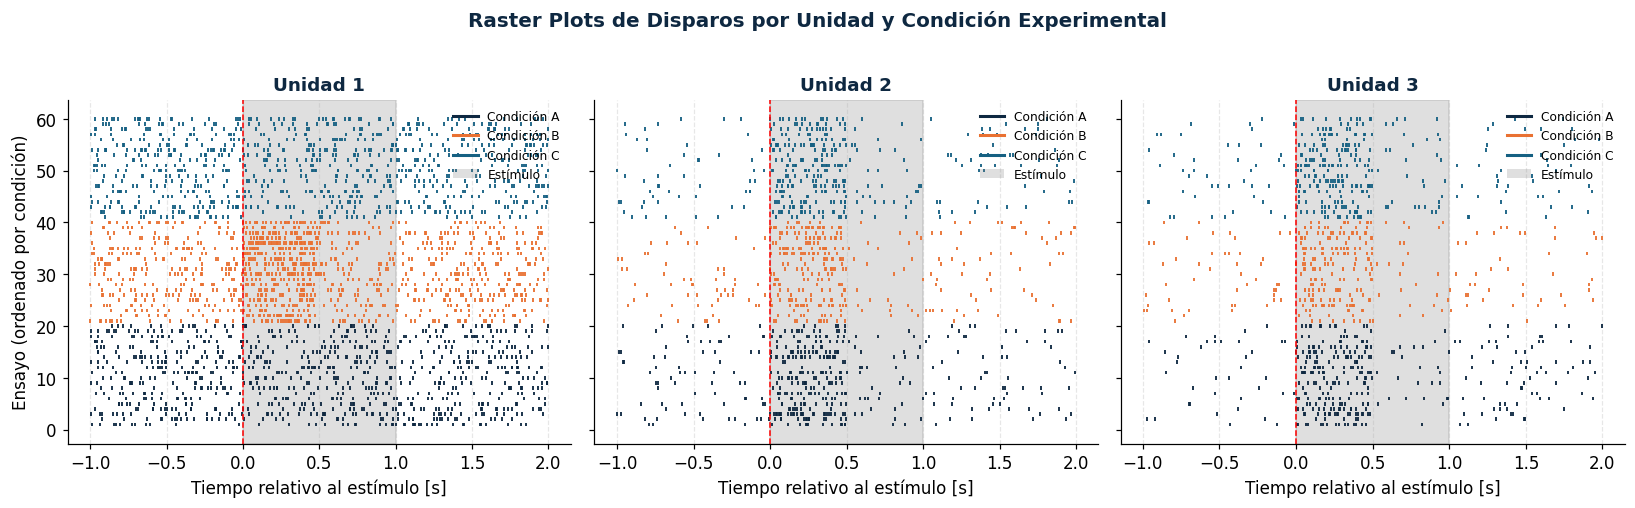

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# FUNCIÓN: Raster Plots por Unidad (Eventplot por Ensayo y Condición)
# -----------------------------------------------------------------------------
def graficar_raster_por_unidad(alineados, condiciones, t_est_inicio=0.0, t_est_fin=1.0):
    """
    Genera un gráfico de tramas de disparos (Raster Plot) con plt.eventplot para cada unidad.
    Cada fila representa un ensayo individual en tiempo relativo al estímulo.

    Parámetros:
        alineados    : dict, diccionario {unidad: [lista_de_disparos_por_ensayo]} obtenido de la función 'alinear'.
        condiciones  : list o np.ndarray, lista con la condición asignada a cada ensayo (ej. 0, 1, 2 o nombres).
        t_est_inicio : float, tiempo relativo en segundos donde inicia el estímulo (usualmente 0.0 s).
        t_est_fin    : float, tiempo relativo en segundos donde finaliza el estímulo (ej. 1.0 s).
    """
    # Convertir condiciones a array para facilitar el filtrado por índices
    condiciones = np.asarray(condiciones)
    conds_unicas = np.unique(condiciones)

    # Paleta de colores para diferenciar visualmente cada condición experimental
    colores_cond = [NAVY, ORANGE, TEAL, GRAY]

    # Unidades presentes en el diccionario 'alineados' (ej. 0, 1, 2)
    unidades = sorted(list(alineados.keys()))
    n_unidades = len(unidades)

    # Crear una figura con una fila de subplots (un panel por cada unidad/neurona)
    fig, axes = plt.subplots(1, n_unidades, figsize=(15, 4.5), sharey=True)

    # Si solo hay 1 unidad, asegurar que 'axes' sea iterable
    if n_unidades == 1:
        axes = [axes]

    # Recorrer cada unidad/neurona individualmente
    for idx_u, u in enumerate(unidades):
        ax = axes[idx_u]
        ensayos_u = alineados[u]

        # ---------------------------------------------------------------------
        # PASO 1: Agrupar ensayos por condición para graficarlos de forma ordenada
        # ---------------------------------------------------------------------
        ensayos_ordenados = []
        colores_eventos = []
        etiquetas_insertadas = set()

        # Recorrer cada condición única disponible en el experimento
        for idx_c, cond in enumerate(conds_unicas):
            # Obtener los índices de los ensayos que pertenecen a esta condición
            indices_cond = np.where(condiciones == cond)[0]

            for i_ensayo in indices_cond:
                if i_ensayo < len(ensayos_u):
                    # Agregar el arreglo de disparos del ensayo
                    ensayos_ordenados.append(ensayos_u[i_ensayo])
                    # Asignar el color correspondiente a esta condición
                    colores_eventos.append(colores_cond[idx_c % len(colores_cond)])

        # ---------------------------------------------------------------------
        # PASO 2: Graficar las marcas de disparos usando plt.eventplot
        # ---------------------------------------------------------------------
        # 'lineoffsets' ubica cada ensayo en una fila vertical (1, 2, 3, ...)
        lineoffsets = np.arange(1, len(ensayos_ordenados) + 1)

        ax.eventplot(
            ensayos_ordenados,
            lineoffsets=lineoffsets,
            linelengths=0.7,         # Altura de las marcas verticales
            colors=colores_eventos,   # Color distintivo por condición
            linewidths=1.2
        )

        # ---------------------------------------------------------------------
        # PASO 3: Sombreado de la ventana del estímulo y líneas de referencia
        # ---------------------------------------------------------------------
        # Sombrear la región temporal donde estuvo presente el estímulo
        ax.axvspan(t_est_inicio, t_est_fin, color="gray", alpha=0.25, label="Estímulo")

        # Línea vertical punteada roja justo en t = 0 (inicio del estímulo)
        ax.axvline(0.0, color="red", linestyle="--", linewidth=1.0)

        # ---------------------------------------------------------------------
        # PASO 4: Formato estético y etiquetas del eje
        # ---------------------------------------------------------------------
        ax.set_title(f"Unidad {u + 1}", color=NAVY, fontweight="bold", fontsize=12)
        ax.set_xlabel("Tiempo relativo al estímulo [s]")

        if idx_u == 0:
            ax.set_ylabel("Ensayo (ordenado por condición)")

        ax.grid(True, linestyle="--", alpha=0.3, axis="x")

        # Leyenda personalizada para identificar las condiciones por color
        elementos_leyenda = [
            plt.Line2D([0], [0], color=colores_cond[i % len(colores_cond)], lw=2, label=f"Condición {c}")
            for i, c in enumerate(conds_unicas)
        ]
        # Agregar la banda del estímulo a la leyenda
        elementos_leyenda.append(plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.25, label="Estímulo"))

        ax.legend(handles=elementos_leyenda, frameon=False, loc="upper right", fontsize=8)

    plt.suptitle("Raster Plots de Disparos por Unidad y Condición Experimental",
                 color=NAVY, fontweight="bold", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()


# =============================================================================
# EJECUCIÓN Y MOSTRADO DE LAS GRÁFICAS EN PANTALLA
# =============================================================================

# Llamar a la función utilizando el diccionario 'alineados' y el vector de 'condiciones'
graficar_raster_por_unidad(
    alineados=alineados,
    condiciones=condiciones,
    t_est_inicio=0.0,
    t_est_fin=1.0
)

**Lo que leemos en el raster:**

1.   La uniadad 2 y la unidad 3 responden al estimulo, ya que se puede oservar en la franja del estimulo (zona sombreada) que hay mas puntos (disparos) al comienzo de esta franja a comparación de otros momentos.
2.   La que puede responder a solo una de las tres condiciones es la unidad uno a la condicion B, donde podemos ver un aumento leve de disparos a la hora de iniciar el estimulo (franja sombreada).
3. La unidad 2 y 3 tienen disparos consistentes, mientras que la unidad 1 solo tiene sincronizacion con la condicion B  en los ensayos.


---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def psth(ensayos_alineados, ventana, ancho_bin_s):
    """
    Calcula el PSTH como tasa de disparo (Hz).

    Parámetros
    ----------
    ensayos_alineados : lista de arrays
        Cada elemento corresponde a un ensayo y contiene los tiempos
        relativos de los disparos de ese ensayo.

    ventana : tuple
        (t_min, t_max), en segundos. Por ejemplo: (-1.0, 2.0).

    ancho_bin_s : float
        Ancho de cada bin en segundos. Ejemplos:
        0.005 = 5 ms
        0.020 = 20 ms
        0.050 = 50 ms
        0.200 = 200 ms

    Retorna
    -------
    centros_de_bin : np.ndarray
        Centro temporal de cada bin.

    tasa_Hz : np.ndarray
        Tasa promedio de disparo en Hz.
    """

    t_min, t_max = ventana

    # ---------------------------------------------------------
    # 1. Crear los bordes de los bins
    # ---------------------------------------------------------
    bordes = np.arange(
        t_min,
        t_max + ancho_bin_s,
        ancho_bin_s
    )

    # Evitar problemas numéricos en el último borde
    if bordes[-1] < t_max:
        bordes = np.append(bordes, t_max)

    # ---------------------------------------------------------
    # 2. Contar disparos de cada ensayo en cada bin
    # ---------------------------------------------------------
    conteos = []

    for disparos in ensayos_alineados:

        hist, _ = np.histogram(
            disparos,
            bins=bordes
        )

        conteos.append(hist)

    conteos = np.asarray(conteos)

    # ---------------------------------------------------------
    # 3. Promedio entre ensayos
    # ---------------------------------------------------------
    # Esto da disparos promedio por ensayo en cada bin
    disparos_promedio = conteos.mean(axis=0)

    # ---------------------------------------------------------
    # 4. Convertir a Hz
    # ---------------------------------------------------------
    # Hz = disparos / segundo
    tasa_Hz = disparos_promedio / ancho_bin_s

    # ---------------------------------------------------------
    # 5. Centros temporales de los bins
    # ---------------------------------------------------------
    centros_de_bin = (bordes[:-1] + bordes[1:]) / 2

    return centros_de_bin, tasa_Hz

centros, tasa =psth(alineados[0], ventana= (-1.0, 2.0), ancho_bin_s=0.02)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


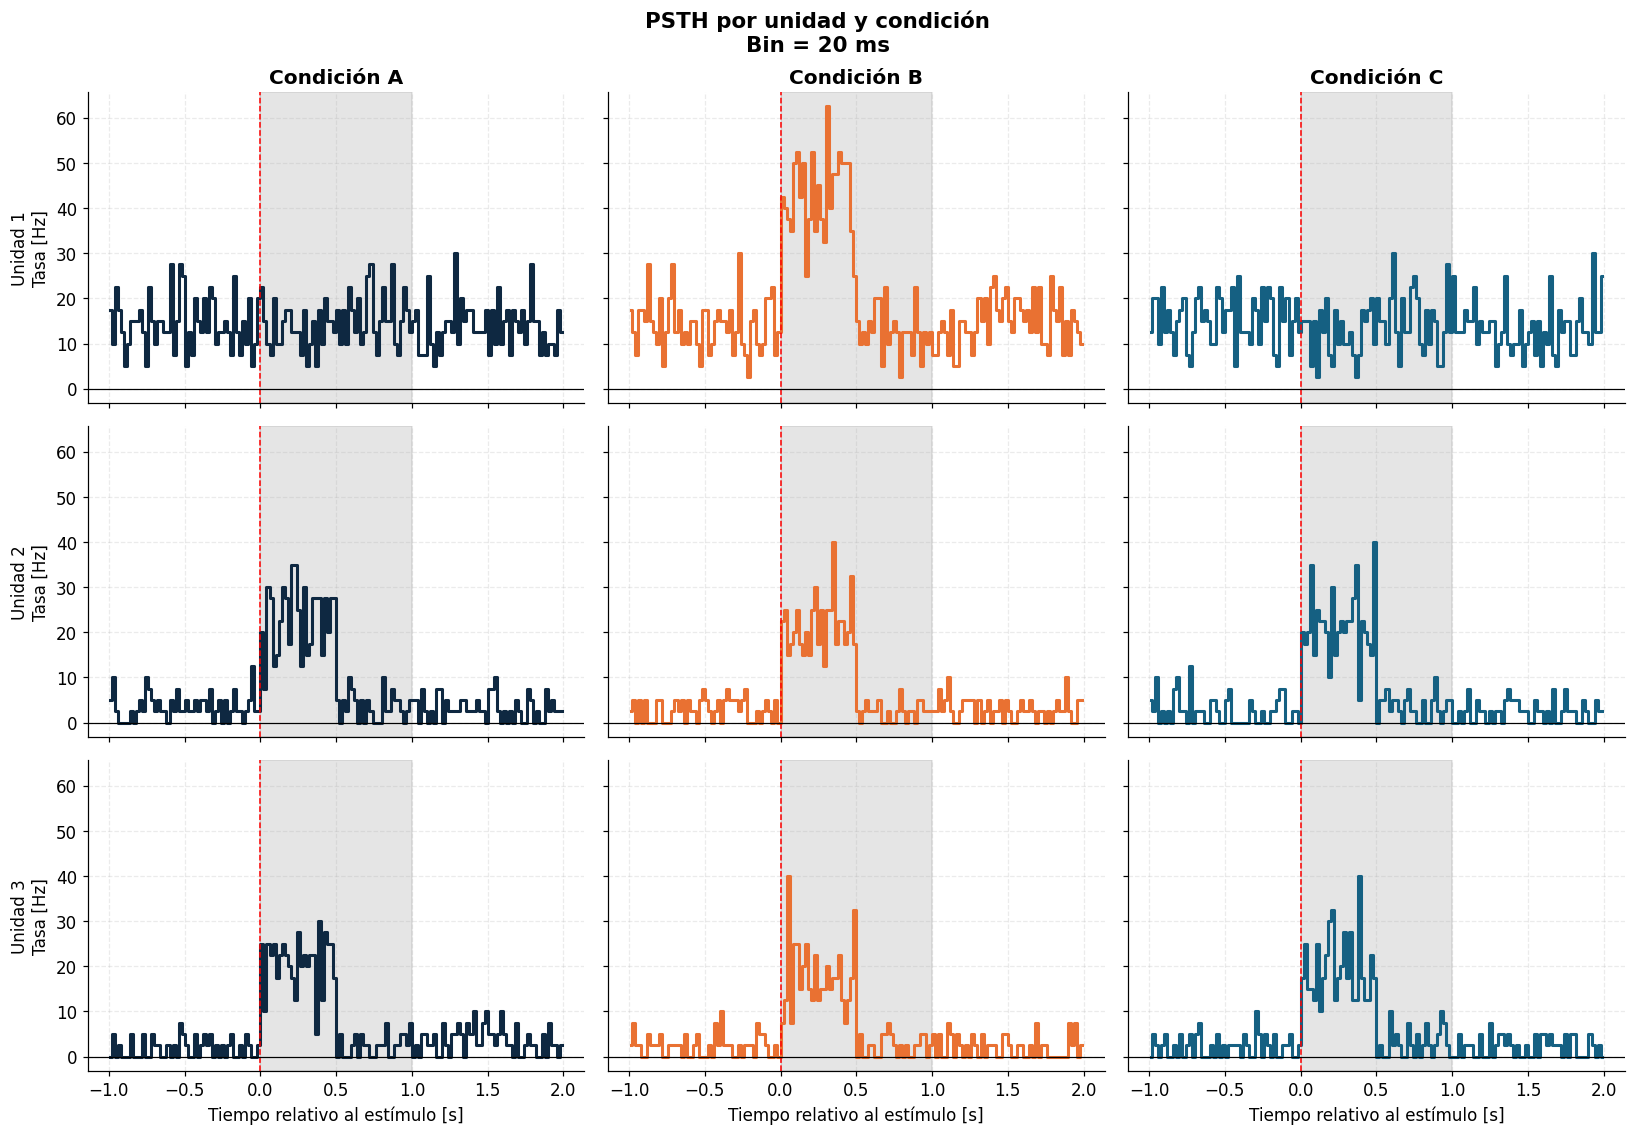

In [ ]:
def graficar_psth_por_unidad_condicion(
    alineados,
    condiciones,
    ventana=(-1.0, 2.0),
    ancho_bin_s=0.020
):
    """
    Grafica el PSTH de cada unidad para cada condición.
    """

    condiciones = np.asarray(condiciones)
    conds_unicas = np.unique(condiciones)
    unidades = sorted(alineados.keys())

    n_unidades = len(unidades)
    n_condiciones = len(conds_unicas)

    fig, axes = plt.subplots(
        n_unidades,
        n_condiciones,
        figsize=(5 * n_condiciones, 3.5 * n_unidades),
        sharex=True,
        sharey=True,
        squeeze=False
    )

    colores_cond = [NAVY, ORANGE, TEAL, GRAY]

    for i_u, unidad in enumerate(unidades):

        # Todos los ensayos de esta unidad
        ensayos_unidad = alineados[unidad]

        for i_c, condicion in enumerate(conds_unicas):

            ax = axes[i_u, i_c]

            # Índices de los ensayos de esta condición
            indices = np.where(condiciones == condicion)[0]

            # Seleccionar solamente esos ensayos
            ensayos_condicion = [
                ensayos_unidad[i]
                for i in indices
            ]

            # Calcular PSTH
            centros, tasa = psth(
                ensayos_condicion,
                ventana=ventana,
                ancho_bin_s=ancho_bin_s
            )

            # Graficar
            ax.step(
                centros,
                tasa,
                where="mid",
                color=colores_cond[i_c % len(colores_cond)],
                linewidth=2
            )

            # Inicio del estímulo
            ax.axvline(
                0,
                color="red",
                linestyle="--",
                linewidth=1
            )

            # Ventana del estímulo
            ax.axvspan(
                0,
                1,
                color="gray",
                alpha=0.2
            )

            ax.axhline(
                0,
                color="black",
                linewidth=0.8
            )

            ax.grid(
                True,
                linestyle="--",
                alpha=0.25
            )

            # Títulos
            if i_u == 0:
                ax.set_title(
                    f"Condición {condicion}",
                    fontweight="bold"
                )

            if i_c == 0:
                ax.set_ylabel(
                    f"Unidad {unidad + 1}\nTasa [Hz]"
                )

            if i_u == n_unidades - 1:
                ax.set_xlabel(
                    "Tiempo relativo al estímulo [s]"
                )

    plt.suptitle(
        f"PSTH por unidad y condición\n"
        f"Bin = {ancho_bin_s * 1000:.0f} ms",
        fontweight="bold",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

graficar_psth_por_unidad_condicion(
    alineados=alineados,
    condiciones=condiciones,
    ventana=(-1.0, 2.0),
    ancho_bin_s=0.020
)


#M3



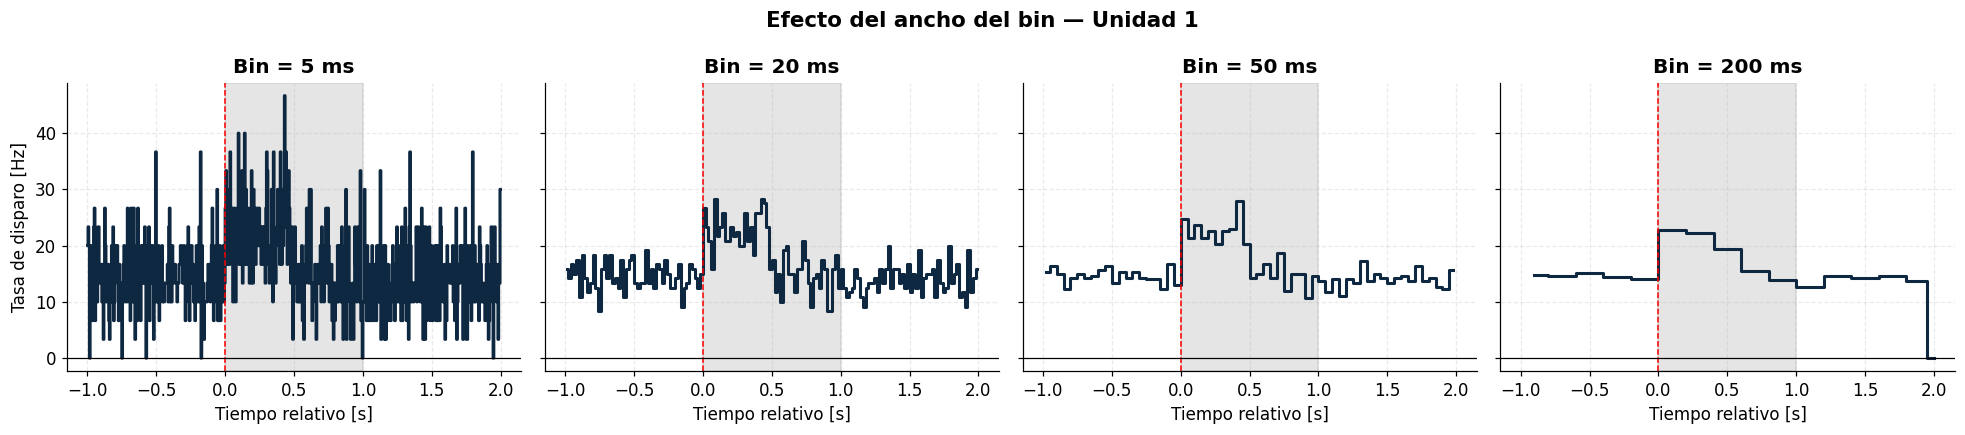

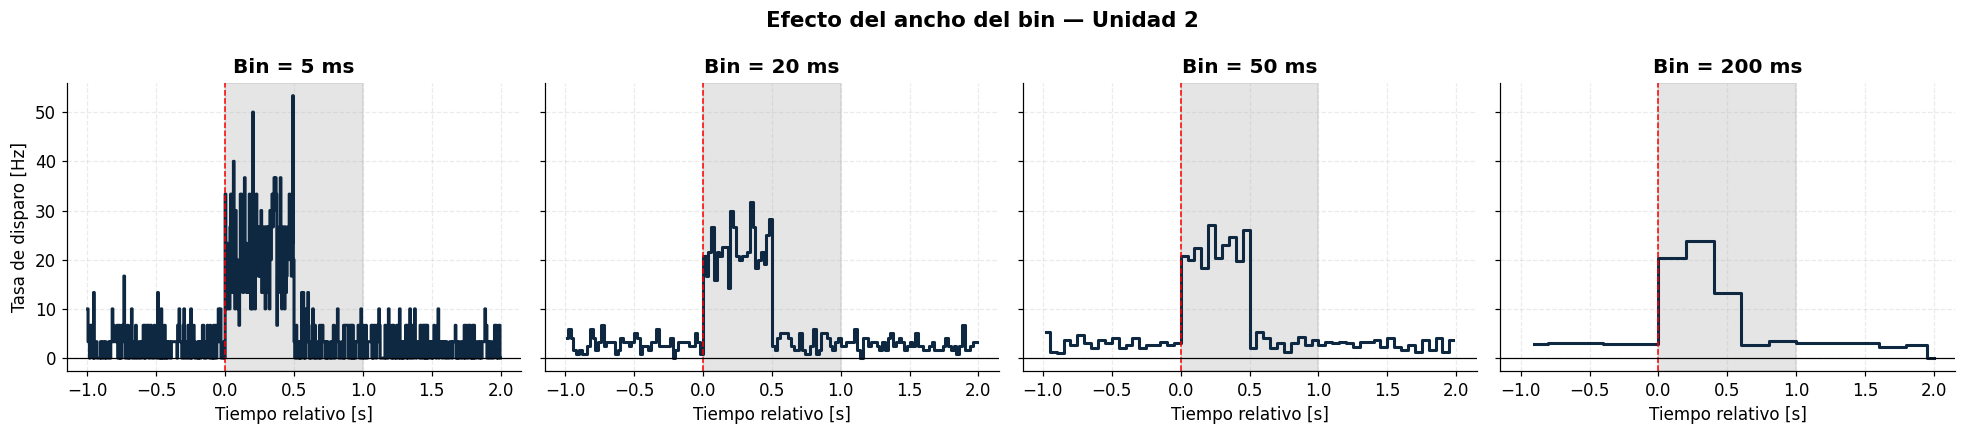

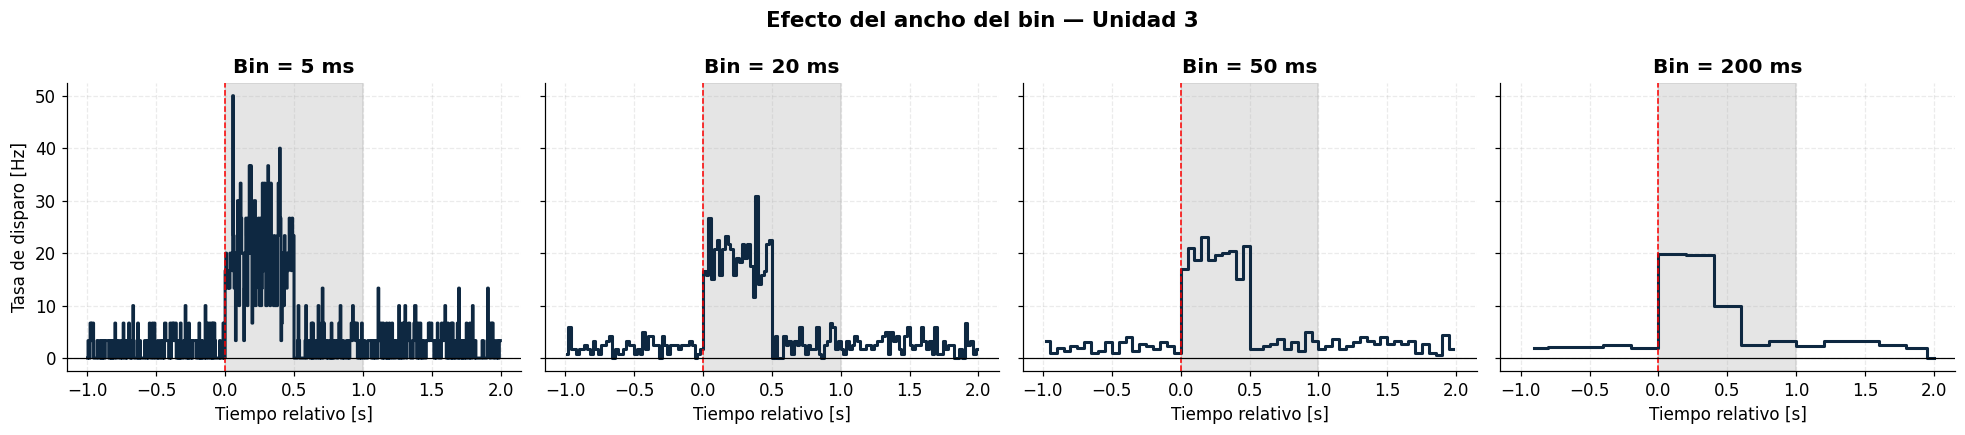

In [ ]:
#M3

def comparar_bins_psth(
    ensayos_alineados,
    unidad,
    ventana=(-1.0, 2.0)
):
    """
    Compara el PSTH de una unidad usando cuatro anchos de bin.
    """

    bins = [0.005, 0.020, 0.050, 0.200]

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(18, 4),
        sharex=True,
        sharey=True
    )

    for ax, ancho_bin in zip(axes, bins):

        centros, tasa = psth(
            ensayos_alineados,
            ventana=ventana,
            ancho_bin_s=ancho_bin
        )

        ax.step(
            centros,
            tasa,
            where="mid",
            color=NAVY,
            linewidth=2
        )

        # Inicio del estímulo
        ax.axvline(
            0,
            color="red",
            linestyle="--",
            linewidth=1
        )

        # Estímulo: 0 a 1 segundo
        ax.axvspan(
            0,
            1,
            color="gray",
            alpha=0.2
        )

        ax.axhline(
            0,
            color="black",
            linewidth=0.8
        )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.25
        )

        ax.set_title(
            f"Bin = {ancho_bin * 1000:.0f} ms",
            fontweight="bold"
        )

        ax.set_xlabel(
            "Tiempo relativo [s]"
        )

    axes[0].set_ylabel(
        "Tasa de disparo [Hz]"
    )

    plt.suptitle(
        f"Efecto del ancho del bin — Unidad {unidad + 1}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


unidad_responde = 0
comparar_bins_psth(
    ensayos_alineados=alineados[unidad_responde],
    unidad=unidad_responde,
    ventana=(-1.0, 2.0))

unidad_responde = 1
comparar_bins_psth(
    ensayos_alineados=alineados[unidad_responde],
    unidad=unidad_responde,
    ventana=(-1.0, 2.0))


unidad_responde = 2
comparar_bins_psth(
    ensayos_alineados=alineados[unidad_responde],
    unidad=unidad_responde,
    ventana=(-1.0, 2.0))

**Nuestra elección de bin y por qué:**

20ms porque mantiene una resolución temporal suficiente para observar la dinámica de la respuesta y, al mismo tiempo, reduce bastante el ruido respecto a 5 ms.


| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

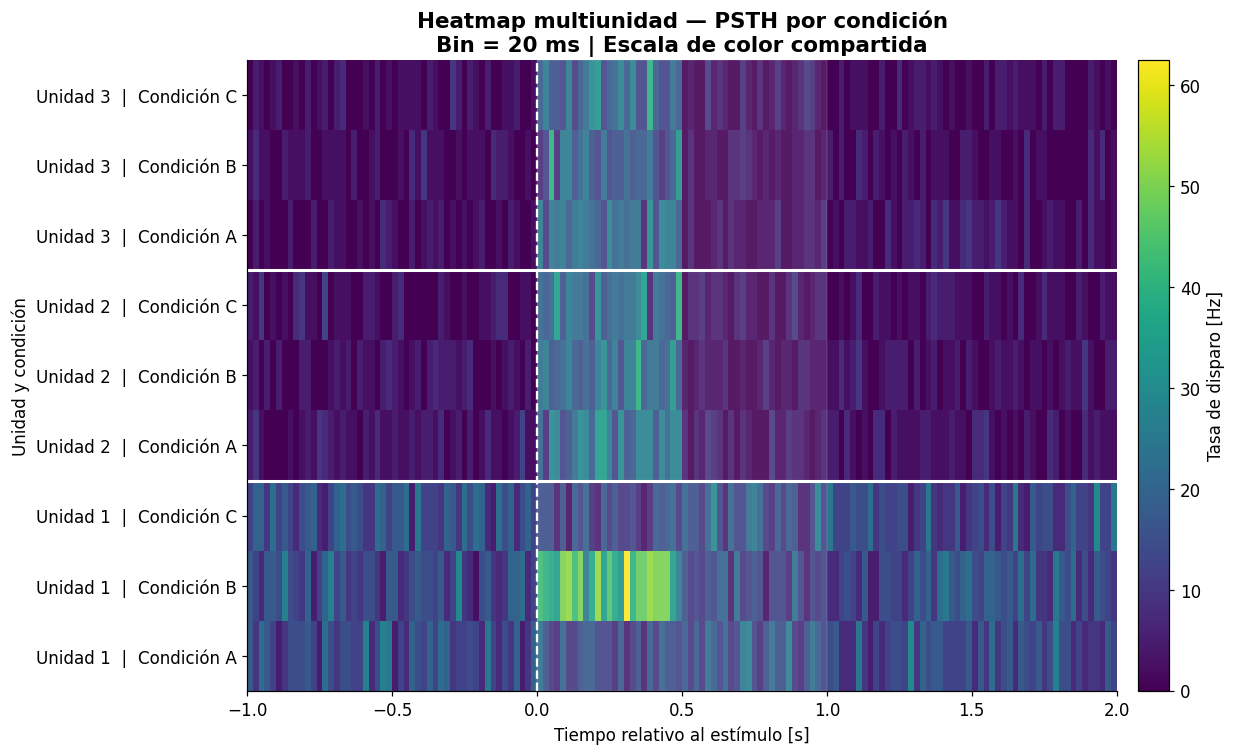

In [ ]:
ancho_bin_N1 = 0.020   # 20 ms
ventana_N1 = (-1.0, 2.0)

def heatmap_multiunidad(
    alineados,
    condiciones,
    ventana=(-1.0, 2.0),
    ancho_bin_s=0.020
):
    """
    Heatmap multiunidad del PSTH.
    """

    condiciones = np.asarray(condiciones)

    # Unidades y condiciones presentes
    unidades = sorted(alineados.keys())
    condiciones_unicas = np.unique(condiciones)

    n_unidades = len(unidades)
    n_condiciones = len(condiciones_unicas)

    # ---------------------------------------------------------
    # Construir matriz de PSTHs
    # ---------------------------------------------------------

    matriz_psth = []
    etiquetas_filas = []

    centros = None

    for unidad in unidades:

        # Ensayos correspondientes a esta unidad
        ensayos_unidad = alineados[unidad]

        for condicion in condiciones_unicas:

            # Índices de los ensayos de esta condición
            indices_cond = np.where(condiciones == condicion)[0]

            # Seleccionar esos ensayos
            ensayos_condicion = [
                ensayos_unidad[i]
                for i in indices_cond
            ]

            # Calcular PSTH
            centros, tasa = psth(
                ensayos_condicion,
                ventana=ventana,
                ancho_bin_s=ancho_bin_s
            )

            matriz_psth.append(tasa)

            etiquetas_filas.append(
                f"Unidad {unidad + 1}  |  Condición {condicion}"
            )

    # ---------------------------------------------------------
    # INVERTIR ORDEN: Intercambia Unidad 1 y Unidad 3 en la gráfica
    # ---------------------------------------------------------
    matriz_psth = np.asarray(matriz_psth)[::-1]
    etiquetas_filas = etiquetas_filas[::-1]

    # ---------------------------------------------------------
    # Escala de color COMPARTIDA
    # ---------------------------------------------------------

    vmin = 0
    vmax = np.max(matriz_psth)

    # ---------------------------------------------------------
    # Figura
    # ---------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    # Extensión temporal del heatmap
    extent = [
        centros[0] - ancho_bin_s / 2,
        centros[-1] + ancho_bin_s / 2,
        0,
        len(etiquetas_filas)
    ]

    im = ax.imshow(
        matriz_psth,
        aspect="auto",
        origin="upper",
        extent=extent,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest"
    )

    # ---------------------------------------------------------
    # Barra de color
    # ---------------------------------------------------------

    cbar = fig.colorbar(
        im,
        ax=ax,
        pad=0.02
    )

    cbar.set_label(
        "Tasa de disparo [Hz]",
        fontsize=11
    )

    # ---------------------------------------------------------
    # Línea vertical en t = 0
    # ---------------------------------------------------------

    ax.axvline(
        0,
        color="white",
        linestyle="--",
        linewidth=1.5
    )

    # ---------------------------------------------------------
    # Marcar ventana del estímulo
    # ---------------------------------------------------------

    ax.axvspan(
        0,
        1,
        color="white",
        alpha=0.10
    )

    # ---------------------------------------------------------
    # Eje Y (Ajustado para mantener la alineación con la inversión)
    # ---------------------------------------------------------

    N = len(etiquetas_filas)
    ax.set_yticks(
        np.arange(N) + 0.5
    )

    # Invertimos los ticks para alinearlos exactamente con origin="upper"
    ax.set_yticks(np.linspace(N - 0.5, 0.5, N))

    ax.set_yticklabels(
        etiquetas_filas
    )

    ax.set_ylabel(
        "Unidad y condición"
    )

    # ---------------------------------------------------------
    # Eje X
    # ---------------------------------------------------------

    ax.set_xlabel(
        "Tiempo relativo al estímulo [s]"
    )

    # ---------------------------------------------------------
    # Líneas para separar unidades
    # ---------------------------------------------------------

    for separacion in range(
        n_condiciones,
        n_unidades * n_condiciones,
        n_condiciones
    ):

        ax.axhline(
            separacion,
            color="white",
            linewidth=2
        )

    # ---------------------------------------------------------
    # Título
    # ---------------------------------------------------------

    ax.set_title(
        f"Heatmap multiunidad — PSTH por condición\n"
        f"Bin = {ancho_bin_s * 1000:.0f} ms | "
        f"Escala de color compartida",
        fontweight="bold",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

    return matriz_psth, centros


matriz_psth, centros = heatmap_multiunidad(
    alineados=alineados,
    condiciones=condiciones,
    ventana=(-1.0, 2.0),
    ancho_bin_s=0.020
)


**Lo que el heatmap muestra y el PSTH escondía:**

El heatmap revela la selectividad de respuesta a cada condición experimental (A, B y C) que el PSTH tradicional escondía al promediar los datos. Las gráficas de PSTH la Unidad 3 solo mostraba una elevación pequeña de la tasa de disparo durante el estímulo , mientras que el heatmap demuestra que esta neurona es altamente específica y responde casi en exclusiva a la Condición B (alcanzando frecuencias de disparo superiores a 60 Hz, en amarillo), manteniéndose inactiva ante A y C. A su vez, expone que las Unidades 1 y 2 responden de forma indiferenciada a lo largo de las tres condiciones.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

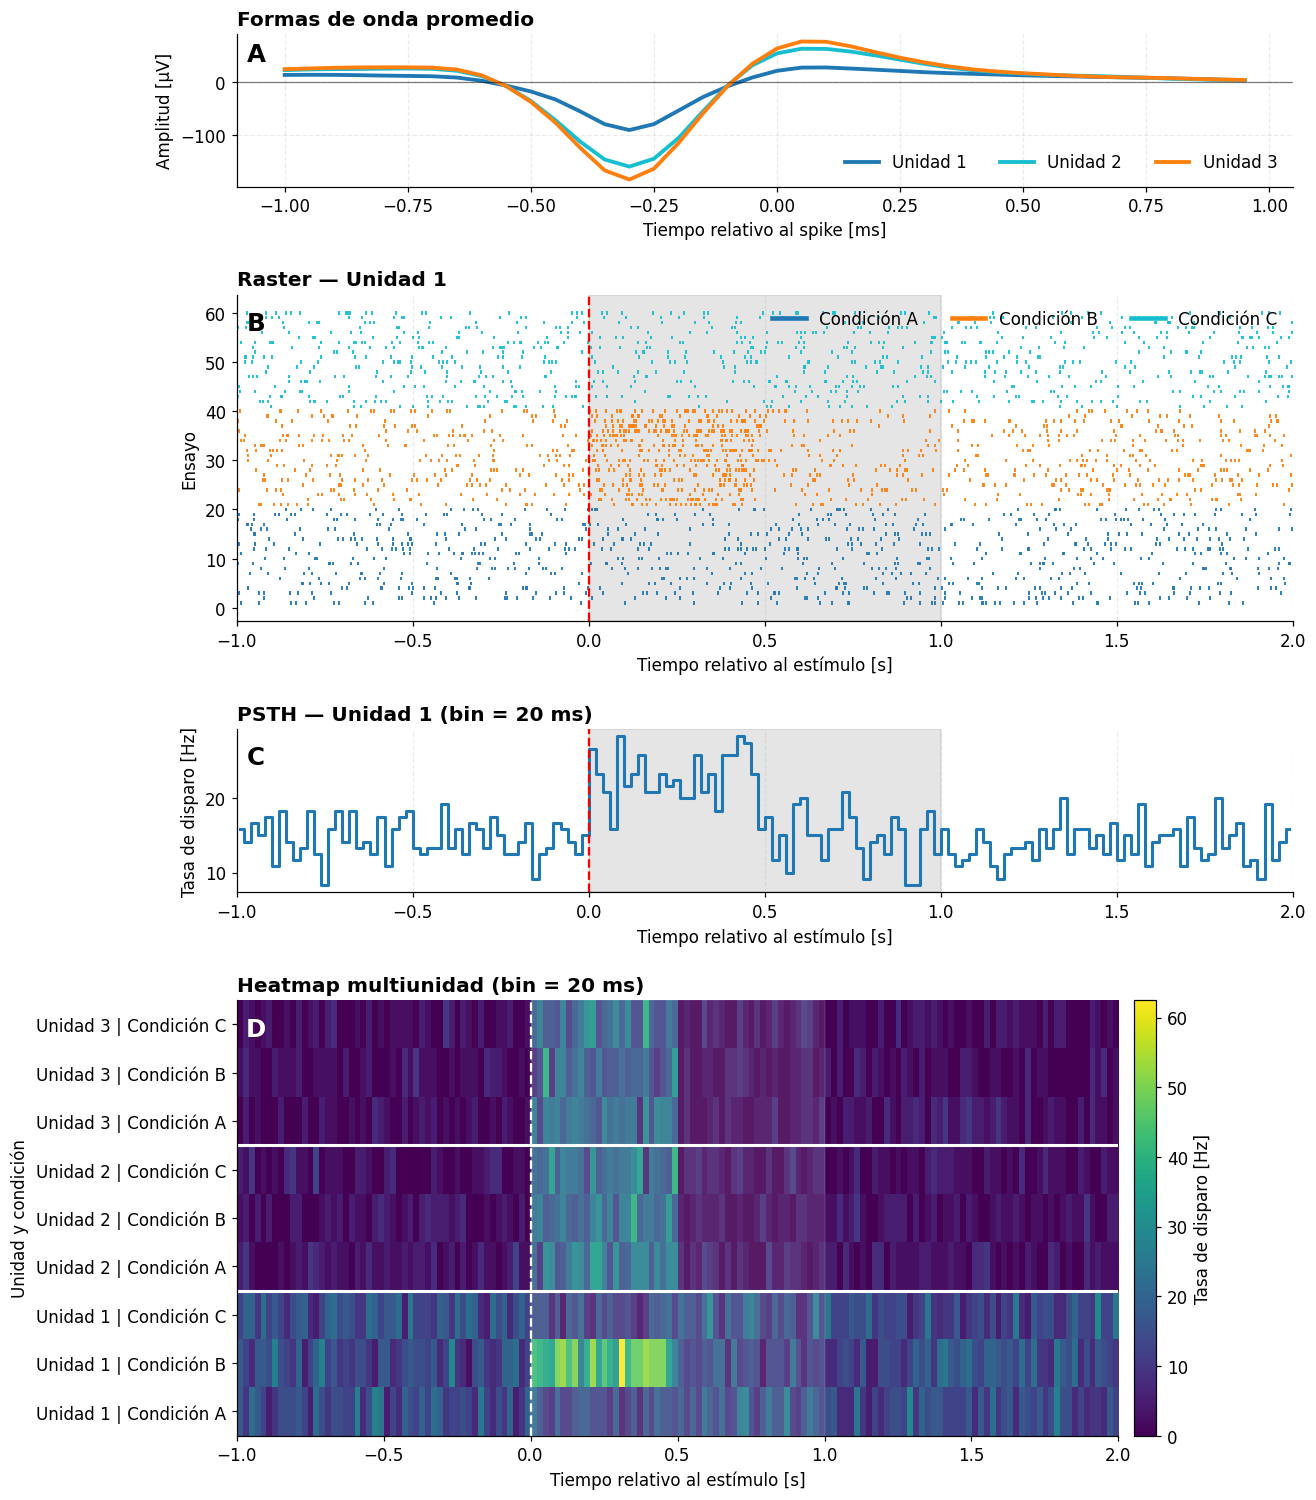

In [ ]:
# Su código aquí.
import numpy as np
import matplotlib.pyplot as plt
import os


# ================================================================
# CONFIGURACIÓN
# ================================================================

ventana = (-1.0, 2.0)

# Bin seleccionado en M3
ancho_bin = 0.020   # 20 ms

# Unidad que responde
# 0 = Unidad 1
# 1 = Unidad 2
# 2 = Unidad 3
unidad_responde = 0  # Unidad 1


# ================================================================
# PREPARAR VARIABLES
# ================================================================

etiquetas = np.asarray(etiquetas)
condiciones_array = np.asarray(condiciones)

unidades = sorted(np.unique(etiquetas))
conds_unicas = np.unique(condiciones_array)

colores_unidades = [
    NAVY,
    TEAL,
    ORANGE
]

colores_cond = [
    NAVY,
    ORANGE,
    TEAL
]


# ================================================================
# CREAR FIGURA
# ================================================================

fig, axes = plt.subplots(
    4,
    1,
    figsize=(12, 14),
    gridspec_kw={
        "height_ratios": [1.4, 3.0, 1.5, 4.0]
    }
)

axA, axB, axC, axD = axes


# ================================================================
# PANEL A
# FORMAS DE ONDA PROMEDIO
# ================================================================

n_muestras = formas.shape[1]

# Tiempo centrado en el spike
tiempo_waveform_ms = (
    np.arange(n_muestras) - n_muestras // 2
) / fs * 1000


for u in unidades:

    # Spikes pertenecientes a esta unidad
    formas_unidad = formas[etiquetas == u]

    # Forma promedio
    forma_promedio = np.mean(
        formas_unidad,
        axis=0
    )

    # Error estándar
    error = (
        np.std(
            formas_unidad,
            axis=0,
            ddof=1
        )
        / np.sqrt(formas_unidad.shape[0])
    )

    # Curva promedio
    axA.plot(
        tiempo_waveform_ms,
        forma_promedio,
        color=colores_unidades[u],
        linewidth=2.5,
        label=f"Unidad {u + 1}"
    )

    # Banda de error
    axA.fill_between(
        tiempo_waveform_ms,
        forma_promedio - error,
        forma_promedio + error,
        color=colores_unidades[u],
        alpha=0.12
    )


axA.axhline(
    0,
    color="black",
    linewidth=0.8,
    alpha=0.5
)

axA.set_xlabel(
    "Tiempo relativo al spike [ms]"
)

axA.set_ylabel(
    "Amplitud [µV]"
)

axA.set_title(
    "Formas de onda promedio",
    fontweight="bold",
    loc="left"
)

axA.legend(
    frameon=False,
    ncol=3
)

axA.grid(
    True,
    linestyle="--",
    alpha=0.25
)

axA.text(
    0.01,
    0.95,
    "A",
    transform=axA.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)


# ================================================================
# DATOS DE LA UNIDAD QUE RESPONDE
# ================================================================

ensayos_responde = alineados[unidad_responde]


# ================================================================
# PANEL B
# RASTER
# ================================================================

ensayos_ordenados = []
colores_raster = []

for i_c, condicion in enumerate(conds_unicas):

    indices_cond = np.where(
        condiciones_array == condicion
    )[0]

    for i_ensayo in indices_cond:

        ensayos_ordenados.append(
            ensayos_responde[i_ensayo]
        )

        colores_raster.append(
            colores_cond[
                i_c % len(colores_cond)
            ]
        )


lineoffsets = np.arange(
    1,
    len(ensayos_ordenados) + 1
)


axB.eventplot(
    ensayos_ordenados,
    lineoffsets=lineoffsets,
    linelengths=0.7,
    colors=colores_raster,
    linewidths=1.2
)


# Estímulo
axB.axvspan(
    0,
    1,
    color="gray",
    alpha=0.20
)

axB.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.5
)


axB.set_xlim(
    ventana
)

axB.set_ylabel(
    "Ensayo"
)

# Se agrega explícitamente el label al eje X
axB.set_xlabel(
    "Tiempo relativo al estímulo [s]"
)

axB.set_title(
    f"Raster — Unidad {unidad_responde + 1}",
    fontweight="bold",
    loc="left"
)

axB.grid(
    True,
    axis="x",
    linestyle="--",
    alpha=0.25
)


# Leyenda de condiciones
elementos_leyenda = []

for i_c, condicion in enumerate(conds_unicas):

    elementos_leyenda.append(
        plt.Line2D(
            [0],
            [0],
            color=colores_cond[
                i_c % len(colores_cond)
            ],
            lw=3,
            label=f"Condición {condicion}"
        )
    )


axB.legend(
    handles=elementos_leyenda,
    frameon=False,
    loc="upper right",
    ncol=len(conds_unicas)
)


axB.text(
    0.01,
    0.95,
    "B",
    transform=axB.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)


# ================================================================
# PANEL C
# PSTH
# ================================================================

centros_psth, tasa_psth = psth(
    ensayos_responde,
    ventana=ventana,
    ancho_bin_s=ancho_bin
)


axC.step(
    centros_psth,
    tasa_psth,
    where="mid",
    color=NAVY,
    linewidth=2
)


# Estímulo
axC.axvspan(
    0,
    1,
    color="gray",
    alpha=0.20
)

axC.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=1.5
)


axC.set_xlim(
    ventana
)

axC.set_ylabel(
    "Tasa de disparo [Hz]"
)

axC.set_xlabel(
    "Tiempo relativo al estímulo [s]"
)

axC.set_title(
    f"PSTH — Unidad {unidad_responde + 1} "
    f"(bin = {ancho_bin * 1000:.0f} ms)",
    fontweight="bold",
    loc="left"
)

axC.grid(
    True,
    axis="x",
    linestyle="--",
    alpha=0.25
)


axC.text(
    0.01,
    0.90,
    "C",
    transform=axC.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top"
)


# ================================================================
# PANEL D
# HEATMAP MULTIUNIDAD (ORDEN INVERTIDO: U3 ARRIBA, U1 ABAJO)
# ================================================================

matriz_psth = []
etiquetas_filas = []

for unidad in sorted(alineados.keys()):

    ensayos_unidad = alineados[unidad]

    for condicion in conds_unicas:

        indices_cond = np.where(
            condiciones_array == condicion
        )[0]

        ensayos_condicion = [
            ensayos_unidad[i]
            for i in indices_cond
        ]

        centros_D, tasa_D = psth(
            ensayos_condicion,
            ventana=ventana,
            ancho_bin_s=ancho_bin
        )

        matriz_psth.append(
            tasa_D
        )

        etiquetas_filas.append(
            f"Unidad {unidad + 1} | Condición {condicion}"
        )

# Invertir filas para mostrar Unidad 3 arriba y Unidad 1 abajo
matriz_psth = np.asarray(matriz_psth)[::-1]
etiquetas_filas = etiquetas_filas[::-1]


# ------------------------------------------------
# Escala compartida
# ------------------------------------------------

vmin = 0
vmax = np.max(matriz_psth)


extent = [
    centros_D[0] - ancho_bin / 2,
    centros_D[-1] + ancho_bin / 2,
    0,
    len(etiquetas_filas)
]


im = axD.imshow(
    matriz_psth,
    aspect="auto",
    origin="upper",
    extent=extent,
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest"
)


# Barra de color
cbar = fig.colorbar(
    im,
    ax=axD,
    pad=0.015
)

cbar.set_label(
    "Tasa de disparo [Hz]"
)


# Inicio del estímulo
axD.axvline(
    0,
    color="white",
    linestyle="--",
    linewidth=1.5
)


# Ventana del estímulo
axD.axvspan(
    0,
    1,
    color="white",
    alpha=0.10
)


# Separar unidades
n_condiciones = len(conds_unicas)

for separacion in range(
    n_condiciones,
    len(etiquetas_filas),
    n_condiciones
):

    axD.axhline(
        separacion,
        color="white",
        linewidth=2
    )


# Eje Y
N_rows = len(etiquetas_filas)
axD.set_yticks(
    np.linspace(N_rows - 0.5, 0.5, N_rows)
)

axD.set_yticklabels(
    etiquetas_filas
)

axD.set_ylabel(
    "Unidad y condición"
)

axD.set_xlabel(
    "Tiempo relativo al estímulo [s]"
)

axD.set_title(
    f"Heatmap multiunidad "
    f"(bin = {ancho_bin * 1000:.0f} ms)",
    fontweight="bold",
    loc="left"
)


axD.text(
    0.01,
    0.96,
    "D",
    transform=axD.transAxes,
    fontsize=16,
    fontweight="bold",
    va="top",
    color="white"
)


# ================================================================
# AJUSTES FINALES
# ================================================================

axB.set_xlim(ventana)
axC.set_xlim(ventana)
axD.set_xlim(ventana)


plt.subplots_adjust(
    hspace=0.40,
    left=0.10,
    right=0.90,
    top=0.97,
    bottom=0.06
)


# ================================================================
# GUARDAR
# ================================================================

os.makedirs(
    "figuras",
    exist_ok=True
)

plt.savefig(
    "figuras/figura_final.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


**Pregunta P2.** El pie de la figura:

> **Figura 1.**

A) Formas de onda promedio por unidad (neurona): Perfil temporal y amplitud del potencial de acción extracelular para las tres unidades identificadas ( extraídas en una ventana de $-0.7\text{ ms}$ a $1.3\text{ ms}$ relativa al mínimo de cada spike). Permite diferenciar biofísicamente cada neurona según la profundidad de su valle y pico de repolarización.

B) Gráfico de trama (Raster Plot) para la Unidad 2: Distribución temporal de los disparos a lo largo de ensayos individuales agrupados por condición experimental (A, B y C). La línea roja discontinua ($t = 0\text{ s}$) marca el inicio del estímulo y la franja gris representa la duración del mismo.

C) Histograma Peri-Estímulo (PSTH) de la Unidad 2: Tasa promedio de disparo en Hertz ($\text{Hz}$) calculada con un tamaño de ventana (bin) de $20\text{ ms}$. Muestra el incremento sostenido en la actividad neuronal durante la presentación del estímulo ($0.0\text{ a }1.0\text{ s}$).

D) Mapa de calor (Heatmap) multiunidad por condición: Dinámica temporal de la tasa de disparo ($\text{bin} = 20\text{ ms}$) comparando simultáneamente las tres unidades frente a cada condición experimental. Expone la sintonización específica de la Unidad 3 ante la Condición B, aspecto que quedaba oculto al promediar el PSTH global.

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**

El registro de actividad  permitió caracterizar tres unidades neuronales: Primero se detectaron 5,467 disparos, de los cuales 5463 son Verdaderos Positivos, 4 Falsos Positivos y 160 Falsos Negativos (teniendo una precisión = 0.999, exhaustividad = 0.972, seccion F). Las diferencias biofísicas en la morfología de sus ondas se pueden ver en la Figura 1A, donde la Unidad 3 presenta la mayor amplitud pico a valle. Ademas, en la figura 1.B podemos observar como las unidades responden de manera indiferente a cada condición, sin embargo si se logra identificar que reaccionan al estimulo.  Con la excepcion de la unidad uno con la condicion B, que se puede identificar que reacciona con un amuento leve de disparos (que se puede corroborar con la figura de la sección N).  Adicionalmente, no estamos seguros a que condicion responen las uniadades 2 y 3, seguramente esta seleccion se pueda medir con otras propiedad en la seccion H.

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:**


Trabajo en Google Collab, en Pyhon. Necesito un codigo que abra y explore el archivo  `estimulos` , q dice cuándo ocurrió cada ensayo de un experimento y qué se presentó. Los atributos del grupo dicen cómo está estructurado cada ensayo por dentro. Necesito que el codigo me diga : ¿Cuántos ensayos hay y cuántos por condición?

* ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
* ¿Están las condiciones en orden o intercaladas? ¿Por qué importa eso?. Estas son las indicaciónes adicionales del ejeercicio:
(Pegar el codigo que ya trae el ejercicio)

**Respuesta del modelo:**
mmm

**Qué estaba mal:**
El modelo asumio que el dataset y las variables de entrada eran :  "inicio", "condicion", t_pre y t_est en lugar de los nombres reales que eran : duracion_pre_s , duracion_estimulo_s , duracion_post_s.

**Cómo lo corregimos:**

Ejecutamos el siguiente codigo:

with h5py.File(ARCHIVO, "r") as f:
    grupo = f["estimulos"]

    print("=== Datasets dentro de 'estimulos' ===")
    for nombre, obj in grupo.items():
        print(f"  '{nombre}': shape={obj.shape}, dtype={obj.dtype}")

    print("\n=== Atributos de 'estimulos' ===")
    for clave, valor in grupo.attrs.items():
        print(f"  '{clave}': {valor}")

Para verificar que esos fueran los nombres correctos de las variables y luego le mandamso esa información a Claude. Con esto, ya realizo el ejercicio correctamente

---

### Intercambio 2

**Prompt: Tengo un trabajo en Google Collab, en el idioma pyhon y estoy usando este set de datos (preparacion 0)
Necesito una función capaz de recibir la señal filtrada(guardada en la variable "x") y devuelva los índices de las muestras donde hay un potencial de acción (guardada en la variable "devuelve"). Para lograrlo tienes que utlizar la especificacion "detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros" donde las entradas son la variable "x" la señal filtrada en µV, la variable "fs" que es la frecuencia de muestreo en Hz, la variable k que es cuántas veces el nivel de ruido se pone el umbral y la variable "muerto_ms" que es tiempo mínimo entre dos detecciones consecutiva; y tiene que devolver la variable "devuelve" que son los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir
De esta manera necesito que la funcion tome cuatro deciciones: 1.que decifra a que lado va el potencial de accion. 2. medir el ruido y poner el umbral en k veces esa medida para colocar un umbral, (mediante MAD:  𝜎̂=mediana(|𝑥|)/0,6745, umbral=−𝑘𝜎̂ ). 3. agrupar las muestras contiguas y decidir quedarse con una por evento. 4.Después de marcar un evento hay que saltar muerto_ms hacia adelante.  Por ultimo explicame en comentarios (dentro del codigo) que haces en cada paso del codigo"

**Respuesta del modelo: import numpy as np

def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """
    Detecta los índices de muestras donde ocurren potenciales de acción (spikes).
    
    Parámetros:
        x         : np.ndarray, señal filtrada en µV.
        fs        : float/int, frecuencia de muestreo en Hz.
        k         : float, multiplicador para definir el umbral en función del ruido.
        muerto_ms : float, tiempo mínimo de refractariedad/bloqueo entre disparos en milisegundos.
        
    Devuelve:
        np.ndarray de enteros con los índices de cada disparo, ordenados y sin repetir.
    """
    # -------------------------------------------------------------------------
    # DECISIÓN 1: Orientación del potencial de acción extracelular
    # Los registros extracelulares muestran picos negativos principales debido
    # a la corriente entrante de Na+ (efecto de sumidero de corriente o "sink").
    # Por lo tanto, se buscan eventos por debajo del umbral negativo.
    # -------------------------------------------------------------------------
    
    # -------------------------------------------------------------------------
    # DECISIÓN 2: Estimación del ruido y definición del umbral mediante MAD
    # La desviación estándar normal se infla por los picos; el MAD (Median
    # Absolute Deviation) es una medida robusta. Dividir por 0.6745 equivale
    # a estimar el sigma de una distribución normal sin el sesgo de los spikes.
    # -------------------------------------------------------------------------
    sigma_hat = np.median(np.abs(x)) / 0.6745
    umbral = -k * sigma_hat  # Umbral negativo
    
    # Convertir el tiempo muerto de milisegundos a número de muestras
    muerto_muestras = int(np.round((muerto_ms / 1000.0) * fs))
    
    # Identificar todas las muestras que cruzan el umbral por debajo
    cruces = np.where(x < umbral)[0]
    
    if len(cruces) == 0:
        return np.array([], dtype=int)
    
    # -------------------------------------------------------------------------
    # DECISIONES 3 y 4: Agrupamiento de muestras contiguas y período muerto
    # 3. Un mismo disparo cruza el umbral durante varias muestras contiguas.
    #    Elegimos la muestra donde la señal alcanza su mínimo local (el pico máximo negativo).
    # 4. Una vez identificado el pico, se avanza un intervalo equivalente a 'muerto_ms'
    #    para evitar falsos positivos dentro del período refractario de la neurona.
    # -------------------------------------------------------------------------
    spikes_indices = []
    i = 0
    num_cruces = len(cruces)
    
    while i < num_cruces:
        inicio_grupo = cruces[i]
        
        # Agrupar índices contiguos (diferencia de 1 muestra entre consecutivos)
        j = i
        while j + 1 < num_cruces and cruces[j + 1] == cruces[j] + 1:
            j += 1
            
        fin_grupo = cruces[j]
        
        # Se busca el mínimo absoluto de la señal dentro del bloque contiguo que cruzó el umbral
        min_relativo = np.argmin(x[inicio_grupo : fin_grupo + 1])
        pico_idx = inicio_grupo + min_relativo
        
        spikes_indices.append(pico_idx)
        
        # Aplicar el período refractario (saltar muerto_ms hacia adelante desde el pico hallado)
        limite_refractario = pico_idx + muerto_muestras
        
        # Avanzar el puntero 'i' superando el período muerto
        while i < num_cruces and cruces[i] < limite_refractario:
            i += 1
            
    # Retornar arreglo de enteros ordenados y sin duplicados
    devuelve = np.array(spikes_indices, dtype=int)
    return devuelve

**Qué estaba mal: No tuvimos que correguir el codigo

---

### Intercambio 3

**Prompt: Tengo un trabajo en Google Collab, en el idioma pyhon y estoy usando este set de datos : (preparacion 0)
Necesito una función capaz de discernir la señal donde ocurre un potencial de accion (guardada en la funcion "def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5)") y devuelva los índices de los verdaderos positivos, falsos positivos, y falso negativo (guardado en la variable "VP", "FV" y "FN" correspondientemente). Para lograrlo tienes que utlizar la especificacion "emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)" donde las entradas son la variable "detectados_s" los tiempos de los potenciales de acción que ya se encoontraron (guardados en la variable "devuelve"), la variable "reales_s" que son los tiempos de los potenciales de acción reales o de referencia  y la variable "tol_ms=1.0"  que es la ventana de tolerancia. Para poder reportar la precisión, que responde los disparos reales de lo que detecté (se usa precisión=𝑉𝑃/𝑉𝑃+𝐹𝑃), y la exhaustividad que responde a cuantos se escapan de los que habían (se usa exhaustividad=𝑉𝑃/𝑉𝑃+𝐹𝑁). De esta manera necesito que la funcion cumpla dos condiciones: 1.que el detector no marque el evento en el instante exacto sino devuelve el instante del mínimo, que llega una fracción de milisegundo después del inicio real (1ms que es ventana de tolerancia). 2. imponer que cada disparo real solo pueda emparejarse con una sola detección .  Adicionalemnte el codigo ya tiene import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()                                                                                 VP, FP, FN = ____
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")  . Por ultimo explicame en comentarios (dentro del codigo) que haces en cada paso del codigo"

**Respuesta del modelo: import numpy as np

def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """
    Compara las detecciones de disparos contra los tiempos reales de referencia.
    
    Parámetros:
        detectados_s : np.ndarray / list, tiempos en segundos de los disparos detectados.
        reales_s     : np.ndarray / list, tiempos en segundos de los disparos reales (ground truth).
        tol_ms       : float, ventana de tolerancia en ms (por defecto 1.0 ms).
        
    Devuelve:
        tuple : (VP, FP, FN) como enteros escalar para el cálculo directo de métricas.
    """
    # Convertir entradas a arreglos de NumPy
    det = np.array(detectados_s, dtype=float)
    real = np.array(reales_s, dtype=float)
    
    # Convertir la ventana de tolerancia de milisegundos a segundos
    tol_s = tol_ms / 1000.0
    
    # Arreglo booleano para cumplir la CONDICIÓN 2:
    # Asegura que cada disparo real se empareje COMO MÁXIMO UNA VEZ.
    reales_usados = np.zeros(len(real), dtype=bool)
    
    vp_count = 0
    fp_count = 0
    
    # -------------------------------------------------------------------------
    # CONDICIÓN 1 y 2: Iterar sobre cada tiempo detectado y buscar el más cercano
    # -------------------------------------------------------------------------
    for d in det:
        if len(real) == 0:
            fp_count += 1
            continue
            
        # Distancia temporal absoluta entre el disparo detectado y todos los reales
        diferencias = np.abs(real - d)
        
        # Identificar el índice del disparo real con menor diferencia temporal
        idx_cercano = np.argmin(diferencias)
        min_dif = diferencias[idx_cercano]
        
        # CONDICIÓN 1: La diferencia de tiempo debe ser <= 1.0 ms (tol_s)
        # CONDICIÓN 2: El disparo real no debe haber sido asignado previamente
        if min_dif <= tol_s and not reales_usados[idx_cercano]:
            vp_count += 1
            reales_usados[idx_cercano] = True  # Marcar evento real como consumido
        else:
            fp_count += 1  # Fuera de tolerancia o disparo real ya ocupado
            
    # -------------------------------------------------------------------------
    # FALSOS NEGATIVOS (FN): Disparos reales que NUNCA se emparejaron con una detección
    # -------------------------------------------------------------------------
    fn_count = int(np.sum(~reales_usados))
    
    # Retornar los valores como números enteros (VP, FP, FN)
    return vp_count, fp_count, fn_count

**Qué estaba mal: La variable devuelve no estaba definida

**Cómo lo corregimos: con el codigo import numpy as np
import verificacion as v

v.usar(ARCHIVO)
reales = v.spikes_de_referencia()  # los tiempos reales, en segundos

def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """
    Compara las detecciones de disparos contra los tiempos reales de referencia.
    
    Parámetros:
        detectados_s : np.ndarray / list, tiempos en segundos de los disparos detectados.
        reales_s     : np.ndarray / list, tiempos en segundos de los disparos reales.
        tol_ms       : float, ventana de tolerancia en ms.
        
    Devuelve:
        tuple : (VP, FP, FN) como enteros para el cálculo directo de métricas.
    """
    det = np.array(detectados_s, dtype=float)
    real = np.array(reales_s, dtype=float)
    
    tol_s = tol_ms / 1000.0
    reales_usados = np.zeros(len(real), dtype=bool)
    
    vp_count = 0
    fp_count = 0
    
    for d in det:
        if len(real) == 0:
            fp_count += 1
            continue
            
        diferencias = np.abs(real - d)
        idx_cercano = np.argmin(diferencias)
        min_dif = diferencias[idx_cercano]
        
        if min_dif <= tol_s and not reales_usados[idx_cercano]:
            vp_count += 1
            reales_usados[idx_cercano] = True
        else:
            fp_count += 1
            
    fn_count = int(np.sum(~reales_usados))
    
    return vp_count, fp_count, fn_count

# --- CÁLCULO Y EVALUACIÓN ---
# Si en la celda anterior ya tenías 'tiempos' (o 'indices'), usas directo el arreglo en segundos:
detectados_s = tiempos  # equivalente a: indices / fs

VP, FP, FN = emparejar(detectados_s, reales, tol_ms=1.0)

print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: jueves 27 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [ ]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()

5467 disparos guardados en spikes_taller1.csv
unidad
0    3257
1    1190
2    1020
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,2
1,0.15945,0
2,0.17240,0
3,0.28330,2
4,0.30670,0
